# Phase 3 — Feature Engineering
## Adaptive Real-Time Financial Transaction Fraud Detection System with Explainable AI, Streaming, Drift Detection and Automated Model Retraining

**Notebook:** `notebooks/03_feature_engineering.ipynb`  |  **Dataset:** PaySim (`PS_20174392719_1491204439457_log.csv`)  |  **Target:** `isFraud`

> **What this notebook does:** turns raw PaySim transactions into a clean, **leakage-safe** feature table for Phase 4 (XGBoost Model V1).
> **What it does NOT do:** train, tune or evaluate any model; resample the data; build Kafka/Spark/API/SHAP/drift/retraining components.

## SECTION 1 — Phase 3 Introduction

### Why feature engineering matters here
Raw PaySim columns are not enough for a real-time fraud system. A model needs *informative* inputs, but in a live system it may only use information that **exists at the moment a transaction is scored**. Phase 2 (EDA) identified three practical constraints that shape everything below:

1. **Leakage:** post-transaction fields (`newbalanceOrig`, `newbalanceDest`) and the label (`isFraud`) must not enter the production feature set.
2. **Identifiers:** `nameOrig` / `nameDest` are high-cardinality IDs. They cannot be one-hot encoded; they become *keys* for behavioural history features.
3. **Time:** transactions are ordered by `step` (1 step = 1 simulated hour). Every history feature must use **past transactions only**.

### Design principles used in this notebook
| Principle | How it is enforced |
|---|---|
| **The label never touches feature code** | `isFraud` is removed from the data (`y`) *before* any feature function runs; the functions physically cannot see it. |
| **Past information only** | Account/velocity features are computed from strictly earlier events in the event order (defined below). A **prefix-invariance test** proves that changing/removing future rows does not change earlier rows' features. |
| **Same code for training and live scoring** | One set of feature functions + fixed parameters. A pure-Python **streaming reference implementation** must reproduce the batch results exactly (Section 21). |
| **Selection never uses the label** | Features are kept/dropped by availability, leakage, variance, and duplication rules — not by their correlation with fraud. |
| **No resampling, no outlier deletion** | Class imbalance is only *reported*; unusual values are preserved. |

### Event order (important for "past only")
PaySim provides only the hourly `step`; the order *inside* one step is not defined by time. We therefore define the **event order** as *(`step`, original row position)*. Future streaming replay must send events in this same order. For a transaction, "past" means **all events earlier in this event order** (previous steps *and* earlier events of the same step). No later event is ever used.

### Where these features go next
`Featured dataset → Phase 4 XGBoost V1 → Kafka/Spark replay (same feature definitions) → SHAP → drift monitoring → retraining`.

> **Time resolution:** PaySim time is hourly. This notebook never invents minutes or seconds, and never invents a real calendar weekday (the simulation start day is unknown).

## SECTION 2 — Import Libraries

In [1]:
import os
import json
import gc
import time
import warnings
from collections import deque
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 100, "savefig.dpi": 150, "axes.titlesize": 12})
pd.options.display.float_format = "{:,.4f}".format
pd.options.display.max_columns = 60
pd.options.display.max_colwidth = 90

print("pandas", pd.__version__, "| numpy", np.__version__)

pandas 2.2.2 | numpy 1.26.4


## SECTION 3 — Configuration

All paths are **relative** and assume this notebook is executed from inside `notebooks/`. Nothing here creates a new project structure; only the existing `data/processed/` and `reports/` folders are used (and only created if somehow missing).

Every number that influences features (windows, thresholds) is defined here once.

In [2]:
DATA_PATH = "../data/raw/PS_20174392719_1491204439457_log.csv"

PROCESSED_PATH = Path("../data/processed/featured_transactions.parquet")
FALLBACK_PROCESSED_PATH = Path("../data/processed/featured_transactions.csv.gz")   # used only if Parquet is unavailable
REPORTS_DIR = Path("../reports")
FIGURES_DIR = REPORTS_DIR / "figures"
FEATURE_DICT_PATH = REPORTS_DIR / "feature_dictionary.csv"
LEAKAGE_AUDIT_PATH = REPORTS_DIR / "feature_leakage_audit.csv"
SELECTED_PATH = REPORTS_DIR / "selected_features.csv"
EXCLUDED_PATH = REPORTS_DIR / "excluded_features.csv"
SUMMARY_PATH = REPORTS_DIR / "feature_engineering_summary.json"

TARGET = "isFraud"
FLAG_COL = "isFlaggedFraud"
META_COLS = ["event_id", "step"]        # kept in the output for chronological splitting; NOT model features
REQUIRED_COLS = ["step", "type", "amount", "nameOrig", "oldbalanceOrg", "newbalanceOrig",
                 "nameDest", "oldbalanceDest", "newbalanceDest", TARGET]

HOURS_PER_DAY = 24                       # PaySim: 1 step = 1 simulated hour
WINDOWS = (1, 24, 168)                   # in steps (hours): 1 = same step, 24 = one simulated day, 168 = one simulated week
SUM_WINDOWS = (24, 168)                  # windows for recent amount totals
NEWCP_WINDOWS = (24, 168)                # windows for "new counterparties" counts
TOL = 0.01                               # currency tolerance for balance equality checks

TRAIN_FRACTION = 0.70                    # chronological share used ONLY to fit constants (thresholds, category list)
LARGE_AMOUNT_QUANTILE = 0.99             # 'large amount' threshold is fitted on the training period only
NZV_THRESHOLD = 0.999                    # feature is near-constant if one value covers >= 99.9% of training rows
CORR_THRESHOLD = 0.98                    # |r| >= threshold -> reported as a highly correlated pair
CORR_SAMPLE = 1_000_000                  # rows used for the correlation review (documented sample)
STREAM_TEST_ROWS = 50_000                # events replayed through the pure-Python streaming reference
PREFIX_TEST_ROWS = 300_000               # size of the prefix used in the "no future information" test
SEED = 42

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_PATH.parent.mkdir(parents=True, exist_ok=True)

CHECK = {}          # tracks which Phase 3 goals were achieved (printed at the end)
PHASE3_START = time.time()


def md(text):
    display(Markdown(text))


def save_fig(fig, name):
    path = FIGURES_DIR / name
    fig.savefig(path, bbox_inches="tight")
    print("Figure saved ->", path)


def pct(part, whole):
    return 100.0 * part / whole if whole else 0.0


print("Data path     :", DATA_PATH)
print("Output dataset:", PROCESSED_PATH)
print("Reports dir   :", REPORTS_DIR)

Data path     : ../data/raw/PS_20174392719_1491204439457_log.csv
Output dataset: ..\data\processed\featured_transactions.parquet
Reports dir   : ..\reports


## SECTION 4 — Load PaySim Dataset

The CSV has ~6.4 million rows, so it is loaded **once** with compact dtypes (small integers, `category`, and Arrow strings for account IDs when `pyarrow` is installed). The label is separated immediately (`pop`, no copy).

In [3]:
def load_dataset(path):
    """Load PaySim efficiently. Fails clearly if the file or a required column is missing."""
    if not Path(path).is_file():
        raise FileNotFoundError(
            f"\nDataset not found at: {Path(path).resolve()}\n"
            "Run this notebook from the 'notebooks/' folder and make sure the CSV is at\n"
            "  ../data/raw/PS_20174392719_1491204439457_log.csv\n")
    header = pd.read_csv(path, nrows=0).columns.tolist()
    missing = [c for c in REQUIRED_COLS if c not in header]
    if missing:
        raise ValueError(f"Required columns missing from the CSV: {missing}. Phase 3 cannot continue without them.")
    dtype_map = {"step": "int32", "type": "category", "amount": "float64", "oldbalanceOrg": "float64",
                 "newbalanceOrig": "float64", "oldbalanceDest": "float64", "newbalanceDest": "float64",
                 "isFraud": "int8", "isFlaggedFraud": "int8"}
    dtypes = {c: t for c, t in dtype_map.items() if c in header}
    try:
        import pyarrow  # noqa: F401
        for c in ("nameOrig", "nameDest"):
            dtypes[c] = "string[pyarrow]"
    except ImportError:
        pass
    try:
        return pd.read_csv(path, dtype=dtypes)
    except (ValueError, TypeError) as exc:
        print("Compact dtypes failed, falling back to inference:", exc)
        return pd.read_csv(path)


df = load_dataset(DATA_PATH)
CHECK["Dataset loaded successfully"] = True
print("Rows   :", f"{len(df):,}")
print("Columns:", df.shape[1])

Rows   : 6,362,620
Columns: 11


## SECTION 5 — Initial Validation

**Purpose:** confirm the file is what Phase 2 analysed, before any feature is built.

In [4]:
print("Column names:", df.columns.tolist())
print("\nData types:")
print(df.dtypes.to_string())
print(f"\nMemory usage: {df.memory_usage(deep=True).sum() / 1024 ** 2:,.1f} MB")
md("**First rows**")
display(df.head())

target_counts = df[TARGET].value_counts()
print("\nTarget distribution:")
print(target_counts.to_string())

checks = {
    "missing cells": int(df.isna().sum().sum()),
    "rows with amount < 0": int((df["amount"] < 0).sum()),
    "rows with step < 1": int((df["step"] < 1).sum()),
    "target values outside {0,1}": int((~df[TARGET].isin([0, 1])).sum()),
    "file already sorted by step": bool(df["step"].is_monotonic_increasing),
    "unexpected transaction types": sorted(set(df["type"].astype(str).unique()) - {"PAYMENT", "TRANSFER", "CASH_OUT", "DEBIT", "CASH_IN"}),
}
for k, v in checks.items():
    print(f"  {k:<32}: {v}")
if checks["missing cells"] or checks["target values outside {0,1}"]:
    print("WARNING: unexpected data-quality issues found; review before trusting downstream results.")

Column names: ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']

Data types:
step                        int32
type                     category
amount                    float64
nameOrig          string[pyarrow]
oldbalanceOrg             float64
newbalanceOrig            float64
nameDest          string[pyarrow]
oldbalanceDest            float64
newbalanceDest            float64
isFraud                      int8
isFlaggedFraud               int8

Memory usage: 509.5 MB


**First rows**

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,"9,839.6400",C1231006815,"170,136.0000","160,296.3600",M1979787155,0.0000,0.0000,0,0
1,1,PAYMENT,"1,864.2800",C1666544295,"21,249.0000","19,384.7200",M2044282225,0.0000,0.0000,0,0
2,1,TRANSFER,181.0000,C1305486145,181.0000,0.0000,C553264065,0.0000,0.0000,1,0
3,1,CASH_OUT,181.0000,C840083671,181.0000,0.0000,C38997010,"21,182.0000",0.0000,1,0
4,1,PAYMENT,"11,668.1400",C2048537720,"41,554.0000","29,885.8600",M1230701703,0.0000,0.0000,0,0



Target distribution:
isFraud
0    6354407
1       8213
  missing cells                   : 0
  rows with amount < 0            : 0
  rows with step < 1              : 0
  target values outside {0,1}     : 0
  file already sorted by step     : True
  unexpected transaction types    : []


## SECTION 6 — Define Target and Raw Columns

* The label is removed from the feature DataFrame **now** (`y`). Feature functions receive only `X_raw`, so the label cannot leak into aggregations, encodings, ratios, behavioural features, scaling or selection.
* `event_id` = original row position in the CSV. It is the stable identity of a transaction (PaySim has no transaction ID) and the key that a streaming replay can also use.
* Data are put in **event order** (stable sort by `step`; if the file is already sorted nothing moves).
* A chronological **training period** (first 70% of transactions) is defined **only to fit constants** (large-amount threshold, category list). Phase 4 owns the real train/validation/test split.

In [5]:
y = df.pop(TARGET).astype("int8")          # label separated in place (no copy of the big frame)
X_raw = df                                  # from here on the frame no longer contains the label
del df
X_raw["event_id"] = np.arange(len(X_raw), dtype="int32")

if not X_raw["step"].is_monotonic_increasing:
    print("File is not sorted by step -> applying a STABLE sort (ties keep original order).")
    order = np.argsort(X_raw["step"].to_numpy(), kind="stable")
    X_raw = X_raw.iloc[order].reset_index(drop=True)
    y = y.iloc[order].reset_index(drop=True)
else:
    print("File is already in chronological (step) order; original row order is the event order.")
assert X_raw["step"].is_monotonic_increasing and len(X_raw) == len(y)
assert TARGET not in X_raw.columns, "The label must not be present in the feature source data"

RAW_INPUT_COLS = [c for c in X_raw.columns if c not in ("event_id",)]
print("\nRaw columns available to feature functions:", RAW_INPUT_COLS)
print("Target kept separately as y:", y.name, "| dtype:", y.dtype)

# training-period boundary (used only for fitting constants)
step_counts = X_raw["step"].value_counts().sort_index()
cum_share = step_counts.cumsum() / step_counts.sum()
TRAIN_END_STEP = int(cum_share[cum_share >= TRAIN_FRACTION].index[0])
TRAIN_MASK = (X_raw["step"] <= TRAIN_END_STEP).to_numpy()
print(f"\nTraining period for fitting constants: step <= {TRAIN_END_STEP} ({TRAIN_MASK.sum():,} rows, {pct(TRAIN_MASK.sum(), len(X_raw)):.1f}%)")

# class imbalance: REPORT ONLY
fraud_n, legit_n = int((y == 1).sum()), int((y == 0).sum())
IMBALANCE = {"legitimate_count": legit_n, "fraud_count": fraud_n, "fraud_percentage": pct(fraud_n, len(y)),
             "imbalance_ratio": (legit_n / fraud_n) if fraud_n else float("inf")}
print(f"\nClass balance (reported only, NOT modified): legitimate={legit_n:,} | fraud={fraud_n:,} | "
      f"fraud={IMBALANCE['fraud_percentage']:.4f}% | ratio=1:{IMBALANCE['imbalance_ratio']:,.1f}")
print("No undersampling, oversampling or SMOTE is performed in Phase 3; Phase 4 decides how to handle imbalance.")
CHECK["Target identified"] = True
CHECK["Chronological ordering preserved"] = True

File is already in chronological (step) order; original row order is the event order.

Raw columns available to feature functions: ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFlaggedFraud']
Target kept separately as y: isFraud | dtype: int8

Training period for fitting constants: step <= 323 (4,463,587 rows, 70.2%)

Class balance (reported only, NOT modified): legitimate=6,354,407 | fraud=8,213 | fraud=0.1291% | ratio=1:773.7
No undersampling, oversampling or SMOTE is performed in Phase 3; Phase 4 decides how to handle imbalance.


## SECTION 7 — Feature Engineering Plan

The plan below is also the **feature registry**: every engineered feature is declared with its group, meaning, prediction-time availability and leakage status *before* it is computed. Later sections check that the computed columns match this registry exactly.

**Leakage status definitions**
| Status | Meaning |
|---|---|
| `SAFE` | Computed from the transaction request itself or from strictly *past* events. Available at scoring time. |
| `POTENTIAL_RISK` | Probably available at scoring time but relies on something not fully verifiable from the data (e.g. the exact timing of a balance snapshot, or a rule-derived flag). Kept only with a documented justification. |
| `UNSAFE` | Uses information produced **by** the transaction (post-transaction balances) or the label. Excluded from the production feature set. |

Unsafe features are still **computed for the audit** so the notebook can show *why* they are dangerous — they are never passed to Phase 4.

In [6]:
FEATURE_SPECS = {}   # name -> dict(group, description, formula, available, status, reason, default_action)


def spec(name, group, description, formula, available, status, reason, default_action="Keep"):
    assert status in ("SAFE", "POTENTIAL_RISK", "UNSAFE")
    FEATURE_SPECS[name] = {"feature_group": group, "description": description, "formula": formula,
                           "prediction_time_available": available, "leakage_status": status,
                           "reason": reason, "default_action": default_action}


# ---- Temporal -----------------------------------------------------------------------------
G = "Temporal"
spec("hour_of_day", G, "Simulated hour within a 24-step cycle (0-23), relative to simulation start.", "(step-1) % 24", "Yes", "SAFE",
     "Derived from the transaction timestamp only.")
spec("hour_sin", G, "Cyclic sine encoding of hour_of_day.", "sin(2*pi*hour/24)", "Yes", "SAFE", "Derived from timestamp only.",
     "Exclude: redundant with hour_of_day for tree models (kept for linear models)")
spec("hour_cos", G, "Cyclic cosine encoding of hour_of_day.", "cos(2*pi*hour/24)", "Yes", "SAFE", "Derived from timestamp only.",
     "Exclude: redundant with hour_of_day for tree models (kept for linear models)")
spec("time_period_bin", G, "Coarse period of the 24-step cycle: 0=hours 0-5, 1=6-11, 2=12-17, 3=18-23 (relative, not clock time).", "hour_of_day // 6",
     "Yes", "SAFE", "Derived from timestamp only.", "Exclude: coarser duplicate of hour_of_day")
spec("day_index", G, "Simulated day number since simulation start (0-based).", "(step-1) // 24", "Yes", "POTENTIAL_RISK",
     "Absolute simulation clock: a model can memorise the simulated month and will not generalise to later periods.",
     "Exclude: absolute time index encourages temporal over-fitting")

# ---- Amount ---------------------------------------------------------------------------------
G = "Amount"
spec("amount", G, "Transaction amount.", "amount", "Yes", "SAFE", "Part of the transaction request.")
spec("log_amount", G, "log(1 + amount); compresses the heavy right tail.", "log1p(amount)", "Yes", "SAFE", "Monotone transform of amount.")
spec("is_zero_amount", G, "1 if amount == 0.", "amount == 0", "Yes", "SAFE", "Derived from amount only.")
spec("is_large_amount", G, "1 if amount >= the training-period 99th percentile (constant fitted on training period only).",
     "amount >= P99(train)", "Yes", "SAFE", "Threshold is a fixed constant stored in the metadata; no future data used.")
spec("amount_to_sender_balance_ratio", G, "Amount divided by the sender's balance BEFORE the transaction (NaN if that balance is 0).",
     "amount / oldbalanceOrg", "Yes (confirm snapshot timing)", "POTENTIAL_RISK",
     "Uses pre-transaction balance; PaySim does not document when the snapshot is taken relative to scoring.")
spec("amount_ge_sender_balance", G, "1 if the amount is >= the sender's pre-transaction balance (and the balance is > 0): the whole balance is requested.",
     "(amount >= oldbalanceOrg - tol) & (oldbalanceOrg > 0)", "Yes (confirm snapshot timing)", "POTENTIAL_RISK", "Uses pre-transaction balance.")
spec("sender_remaining_if_debited", G, "Balance the sender WOULD have if the amount were debited (expected, not observed).",
     "oldbalanceOrg - amount", "Yes (confirm snapshot timing)", "POTENTIAL_RISK",
     "Built from pre-transaction balance and amount only; never from newbalanceOrig.")
spec("amount_to_dest_balance_ratio", G, "Amount divided by the destination's balance BEFORE the transaction (NaN if that balance is 0).",
     "amount / oldbalanceDest", "Yes (confirm snapshot timing)", "POTENTIAL_RISK", "Uses pre-transaction balance of the recipient.")

# ---- Sender balance -------------------------------------------------------------------------
G = "Sender balance"
spec("sender_balance_before", G, "Sender balance before the transaction.", "oldbalanceOrg", "Yes (confirm snapshot timing)", "POTENTIAL_RISK",
     "Pre-transaction state; snapshot timing not documented.")
spec("sender_balance_zero_before", G, "1 if the sender's balance before the transaction is 0.", "oldbalanceOrg == 0", "Yes (confirm snapshot timing)",
     "POTENTIAL_RISK", "Pre-transaction state.")
spec("sender_balance_change", G, "Observed change in sender balance.", "newbalanceOrig - oldbalanceOrg", "No", "UNSAFE",
     "Uses newbalanceOrig, an outcome of the transaction.", "Exclude: post-transaction information")
spec("sender_balance_ratio", G, "Sender balance after / before.", "newbalanceOrig / oldbalanceOrg", "No", "UNSAFE",
     "Uses newbalanceOrig, an outcome of the transaction.", "Exclude: post-transaction information")
spec("sender_balance_zero_after", G, "1 if the sender's balance after the transaction is 0.", "newbalanceOrig == 0", "No", "UNSAFE",
     "Uses newbalanceOrig, an outcome of the transaction.", "Exclude: post-transaction information")
spec("sender_balance_consistency", G, "Accounting error on the sender side.", "oldbalanceOrg - amount - newbalanceOrig", "No", "UNSAFE",
     "Uses newbalanceOrig; the inconsistency itself is produced by how the transaction was recorded.", "Exclude: post-transaction information")

# ---- Destination balance --------------------------------------------------------------------
G = "Destination balance"
spec("dest_balance_before", G, "Recipient balance before the transaction.", "oldbalanceDest", "Yes (confirm snapshot timing)", "POTENTIAL_RISK",
     "Pre-transaction state; zeros may mean 'untracked' (Phase 2).")
spec("dest_balance_zero_before", G, "1 if the recipient's balance before the transaction is 0.", "oldbalanceDest == 0", "Yes (confirm snapshot timing)",
     "POTENTIAL_RISK", "Pre-transaction state.")
spec("dest_balance_change", G, "Observed change in recipient balance.", "newbalanceDest - oldbalanceDest", "No", "UNSAFE",
     "Uses newbalanceDest, an outcome of the transaction.", "Exclude: post-transaction information")
spec("dest_balance_zero_after", G, "1 if the recipient's balance after the transaction is 0.", "newbalanceDest == 0", "No", "UNSAFE",
     "Uses newbalanceDest, an outcome of the transaction.", "Exclude: post-transaction information")
spec("dest_balance_consistency", G, "Accounting error on the recipient side.", "oldbalanceDest + amount - newbalanceDest", "No", "UNSAFE",
     "Uses newbalanceDest.", "Exclude: post-transaction information")

# ---- Account behaviour + velocity (generated for sender and destination) ------------------------
for role, cp in (("sender", "destinations"), ("dest", "senders")):
    who = "sender" if role == "sender" else "destination"
    G = "Account behaviour"
    spec(f"{role}_prev_txn_count", G, f"Number of earlier transactions of this {who} account.", "count of earlier events", "Yes (needs streaming state)", "SAFE",
         "Uses strictly earlier events only.")
    spec(f"{role}_prev_total_amount", G, f"Total amount of earlier transactions of this {who} account.", "sum of earlier amounts", "Yes (needs streaming state)", "SAFE",
         "Uses strictly earlier events only.")
    spec(f"{role}_prev_mean_amount", G, f"Mean amount of earlier transactions of this {who} account (NaN if none).", "mean of earlier amounts", "Yes (needs streaming state)",
         "SAFE", "Uses strictly earlier events only.")
    spec(f"{role}_prev_max_amount", G, f"Largest earlier amount of this {who} account (NaN if none).", "max of earlier amounts", "Yes (needs streaming state)", "SAFE",
         "Uses strictly earlier events only.")
    spec(f"{role}_prev_unique_counterparties", G, f"Distinct {cp} this {who} account has already transacted with.", "count of first-ever pairs so far",
         "Yes (needs streaming state)", "SAFE", "Uses strictly earlier events only.")
    G = "Velocity"
    spec(f"{role}_hours_since_prev_txn", G, f"Steps (hours) since the previous transaction of this {who} account (NaN if none).", "step - previous step",
         "Yes (needs streaming state)", "SAFE", "Uses strictly earlier events only.")
    for W in WINDOWS:
        spec(f"{role}_txn_count_last_{W}h", G, f"Earlier transactions of this {who} account within the last {W} step(s)" + (" (same step only)." if W == 1 else "."),
             f"count of earlier events with step > step-{W}", "Yes (needs streaming state)", "SAFE", "Uses strictly earlier events only.")
    for W in SUM_WINDOWS:
        spec(f"{role}_amount_sum_last_{W}h", G, f"Total amount of earlier transactions of this {who} account within the last {W} steps.",
             f"sum of earlier amounts with step > step-{W}", "Yes (needs streaming state)", "SAFE", "Uses strictly earlier events only.")
    for W in NEWCP_WINDOWS:
        spec(f"{role}_new_counterparties_last_{W}h", G, f"Earlier transactions in the last {W} steps in which this {who} account met a {cp[:-1]} for the FIRST EVER time.",
             "count of earlier first-ever pairs in window", "Yes (needs streaming state)", "SAFE", "Uses strictly earlier events only.")

G = "Account behaviour"
spec("is_new_destination_for_sender", G, "1 if this sender has never paid this destination before (first-ever sender->destination pair).", "pair not seen in earlier events",
     "Yes (needs streaming state)", "SAFE", "Uses strictly earlier events only.")
spec("amount_vs_sender_hist_mean", G, "Amount divided by the sender's earlier mean amount (NaN if no history).", "amount / sender_prev_mean_amount",
     "Yes (needs streaming state)", "SAFE", "Uses the current amount and earlier events only.")
spec("amount_vs_dest_hist_mean", G, "Amount divided by the destination's earlier mean received amount (NaN if no history).", "amount / dest_prev_mean_amount",
     "Yes (needs streaming state)", "SAFE", "Uses the current amount and earlier events only.")

# ---- Transaction type (filled once the categories are fitted) ----------------------------------
for t in ("PAYMENT", "TRANSFER", "CASH_OUT", "DEBIT", "CASH_IN"):
    spec(f"type_{t}", "Transaction type", f"One-hot indicator: type == {t}.", f"type == '{t}'", "Yes", "SAFE", "Part of the transaction request.")

# ---- Non-frame rows kept for the leakage audit (not engineered columns) ---------------------------
NON_FRAME_SPECS = {
    TARGET: {"feature_group": "Target", "description": "Ground-truth label (1 = fraud).", "prediction_time_available": "No (delayed label)",
             "leakage_status": "UNSAFE", "reason": "It IS the answer; in production it arrives later.", "default_action": "Target only (never an input feature)"},
    FLAG_COL: {"feature_group": "Rule-derived flag", "description": "Existing rule-based fraud flag.", "prediction_time_available": "Needs investigation",
               "leakage_status": "POTENTIAL_RISK", "reason": "Rule output with undocumented timing; model could reproduce the rule (decision in Section 15).",
               "default_action": "Decided in Section 15"},
    "step": {"feature_group": "Metadata", "description": "Chronological key (simulated hour).", "prediction_time_available": "Yes", "leakage_status": "SAFE",
             "reason": "Known at event time; used only for ordering/splitting.", "default_action": "Meta (not a model feature)"},
    "event_id": {"feature_group": "Metadata", "description": "Original row position; identity of a transaction.", "prediction_time_available": "Yes",
                 "leakage_status": "SAFE", "reason": "Identifier only; must not be a model feature.", "default_action": "Meta (not a model feature)"},
}

plan = pd.DataFrame([{"feature": k, **{kk: vv for kk, vv in v.items() if kk in ("feature_group", "prediction_time_available", "leakage_status")}}
                     for k, v in FEATURE_SPECS.items()])
print(f"Planned engineered features: {len(plan)}")
display(plan.groupby(["feature_group", "leakage_status"]).size().unstack(fill_value=0))

Planned engineered features: 58


leakage_status,POTENTIAL_RISK,SAFE,UNSAFE
feature_group,,,
Account behaviour,0,13,0
Amount,4,4,0
Destination balance,2,0,3
Sender balance,2,0,4
Temporal,1,4,0
Transaction type,0,5,0
Velocity,0,16,0


### SECTION 7 (continued) — Constants fitted on the training period only

A few features need a *constant* learned from data (the "large amount" threshold and the list of transaction types). To avoid any leakage from the future, these constants are fitted **only on the chronological training period** and then **frozen**. The same frozen constants are reused for validation/test data and for live transactions, and are saved to the metadata file.

In [7]:
def fit_feature_params(raw, train_mask):
    """Fit frozen constants on the training period only."""
    types = sorted(raw.loc[train_mask, "type"].astype(str).unique().tolist())
    return {"large_amount_threshold": float(raw.loc[train_mask, "amount"].quantile(LARGE_AMOUNT_QUANTILE)),
            "type_categories": types,
            "tolerance": TOL, "windows": list(WINDOWS), "sum_windows": list(SUM_WINDOWS), "newcp_windows": list(NEWCP_WINDOWS),
            "hours_per_day": HOURS_PER_DAY, "retain_flag_feature": False,
            "train_end_step": TRAIN_END_STEP, "train_fraction": TRAIN_FRACTION}


FE_PARAMS = fit_feature_params(X_raw, TRAIN_MASK)
print(json.dumps(FE_PARAMS, indent=2))

# keep the registry consistent with the fitted category list
for t in FE_PARAMS["type_categories"]:
    if f"type_{t}" not in FEATURE_SPECS:
        spec(f"type_{t}", "Transaction type", f"One-hot indicator: type == {t}.", f"type == '{t}'", "Yes", "SAFE", "Part of the transaction request.")
for k in [k for k in FEATURE_SPECS if k.startswith("type_") and k[5:] not in FE_PARAMS["type_categories"]]:
    print(f"Registry entry {k} removed: category not present in the training period.")
    del FEATURE_SPECS[k]

{
  "large_amount_threshold": 1452542.9963999956,
  "type_categories": [
    "CASH_IN",
    "CASH_OUT",
    "DEBIT",
    "PAYMENT",
    "TRANSFER"
  ],
  "tolerance": 0.01,
  "windows": [
    1,
    24,
    168
  ],
  "sum_windows": [
    24,
    168
  ],
  "newcp_windows": [
    24,
    168
  ],
  "hours_per_day": 24,
  "retain_flag_feature": false,
  "train_end_step": 323,
  "train_fraction": 0.7
}


## SECTION 8 — Temporal Features

| Feature | Meaning | Why it may help | Calculation | Prediction-time | Leakage risk |
|---|---|---|---|---|---|
| `hour_of_day` | Position inside a 24-step cycle | Fraud and legitimate traffic may follow different daily rhythms (Phase 2 compared them) | `(step-1) % 24` | Yes | None |
| `hour_sin`, `hour_cos` | Cyclic encoding (hour 23 is next to hour 0) | Needed by models that assume linear order | sin/cos of `2π·hour/24` | Yes | None |
| `time_period_bin` | 6-hour block of the cycle | Coarse, more stable version of the hour | `hour // 6` | Yes | None |
| `day_index` | Simulated day since start | Trend analysis only | `(step-1) // 24` | Yes | **Potential risk**: absolute time → temporal over-fitting |

* The raw `step` is **kept as metadata** (chronological key for splitting/replay) but is not a model feature.
* PaySim time is hourly: no minute/second features are created, and no weekday is created because the simulation's start day is unknown.
* "Hour of day" is relative to the simulation start — it is *not* a real clock time.

Temporal features created in 0.8s


,dtype,nan_%,mean,median,min,max,zero_%
feature,,,,,,,
hour_of_day,int8,0.0000,14.5915,15.0000,0.0000,23.0000,0.4261
hour_sin,float32,0.0000,-0.3554,-0.5000,-1.0000,1.0000,0.4261
hour_cos,float32,0.0000,-0.4091,-0.5000,-1.0000,1.0000,0.0000
time_period_bin,int8,0.0000,2.0147,2.0000,0.0000,3.0000,0.6984
day_index,int16,0.0000,9.4919,9.0000,0.0000,30.0000,9.0254


Figure saved -> ..\reports\figures\p3_01_temporal_features.png


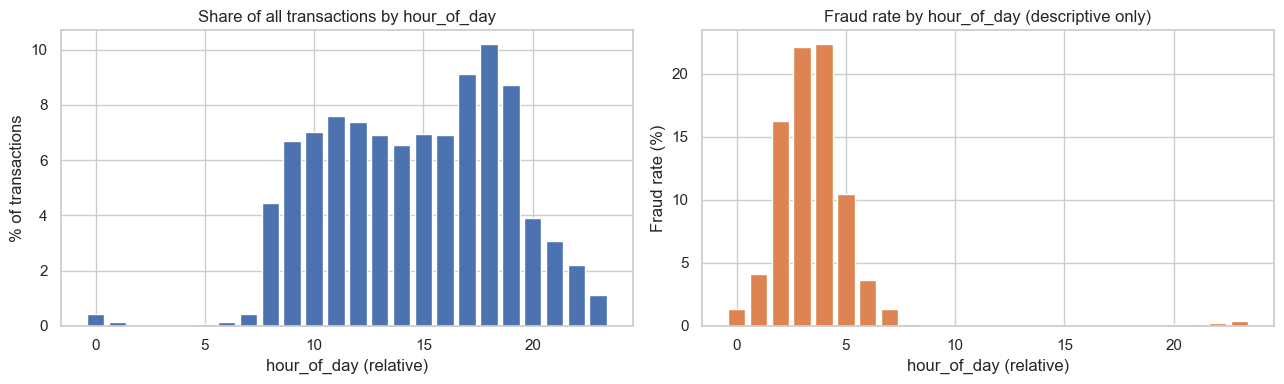

In [8]:
def create_temporal_features(raw, params):
    """Row-level temporal features from `step` (hourly simulated time)."""
    step = raw["step"].to_numpy(dtype=np.int64)
    hpd = params["hours_per_day"]
    hour = (step - 1) % hpd
    return pd.DataFrame({
        "hour_of_day": hour.astype("int8"),
        "hour_sin": np.sin(2 * np.pi * hour / hpd).astype("float32"),
        "hour_cos": np.cos(2 * np.pi * hour / hpd).astype("float32"),
        "time_period_bin": (hour // 6).astype("int8"),
        "day_index": ((step - 1) // hpd).astype("int16"),
    }, index=raw.index)


COLORS = {0: "#4C72B0", 1: "#C44E52"}
CLASS_NAMES = {0: "Legitimate", 1: "Fraud"}
y_arr = y.to_numpy()


def summarise_part(part):
    """Compact per-feature summary (dtype, NaN %, mean, median, min, max, % zeros)."""
    rows = []
    for c in part.columns:
        s = part[c]
        rows.append({"feature": c, "dtype": str(s.dtype), "nan_%": pct(int(s.isna().sum()), len(s)), "mean": s.mean(), "median": s.median(),
                     "min": s.min(), "max": s.max(), "zero_%": pct(int((s == 0).sum()), len(s))})
    return pd.DataFrame(rows).set_index("feature")


def plot_class_hist(ax, values, y_values, title, xlabel, transform=None, bins=50, upper_q=99.9):
    """Full-data histogram per class (each class normalised to 1). Tails beyond the 0.1-99.9th percentile are pooled in the end bins."""
    v = np.asarray(values, dtype="float64").copy()
    ok = np.isfinite(v)
    if transform == "log10":
        ok &= v > 0
        v = np.log10(np.where(ok, v, 1.0))
    elif transform == "log1p":
        ok &= v >= 0
        v = np.log1p(np.where(ok, v, 0.0))
    if not ok.any():
        ax.text(0.5, 0.5, "no defined values", ha="center")
        return
    lo, hi = np.percentile(v[ok], [0.1, upper_q])
    if hi <= lo:
        hi = lo + 1
    edges = np.linspace(lo, hi, bins + 1)
    for cls in (0, 1):
        m = ok & (y_values == cls)
        if m.sum() == 0:
            continue
        cnt, _ = np.histogram(np.clip(v[m], lo, hi), bins=edges)
        ax.stairs(cnt / cnt.sum(), edges, fill=True, alpha=0.45, color=COLORS[cls], label=f"{CLASS_NAMES[cls]} (n={int(m.sum()):,})")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Proportion within class")
    ax.legend(fontsize=8)


PARTS = {}
t0 = time.time()
PARTS["temporal"] = create_temporal_features(X_raw, FE_PARAMS)
print(f"Temporal features created in {time.time() - t0:.1f}s")
display(summarise_part(PARTS["temporal"]))

hour = PARTS["temporal"]["hour_of_day"].to_numpy()
hour_tbl = pd.DataFrame({"hour": hour, "y": y_arr}).groupby("hour")["y"].agg(["size", "sum"])
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(hour_tbl.index, 100 * hour_tbl["size"] / hour_tbl["size"].sum(), color=COLORS[0])
axes[0].set(title="Share of all transactions by hour_of_day", xlabel="hour_of_day (relative)", ylabel="% of transactions")
axes[1].bar(hour_tbl.index, 100 * hour_tbl["sum"] / hour_tbl["size"], color="#DD8452")
axes[1].set(title="Fraud rate by hour_of_day (descriptive only)", xlabel="hour_of_day (relative)", ylabel="Fraud rate (%)")
plt.tight_layout()
save_fig(fig, "p3_01_temporal_features.png")
plt.show()
CHECK["Temporal features created"] = True

**Observation.** The left panel is the *legitimate-dominated* traffic profile; the right panel shows how the fraud **rate** varies inside the cycle. If the two shapes differ, `hour_of_day` carries information; the chart is descriptive and does not prove predictive value (Phase 4 will test that).

**Availability / leakage:** every temporal feature is computable from the transaction timestamp alone → available for live transactions. `day_index` is flagged `POTENTIAL_RISK` and excluded by design.

## SECTION 9 — Transaction Amount Features

| Feature | Meaning | Why it may help | Calculation | Prediction-time | Leakage risk |
|---|---|---|---|---|---|
| `amount` | Requested value | Core signal; heavy right tail (Phase 2) | raw | Yes | None |
| `log_amount` | Compressed amount | Readable distribution; useful for other model families and drift monitoring | `log1p(amount)` | Yes | None |
| `is_zero_amount` | Zero-value transaction | Possible probing transactions | `amount == 0` | Yes | None |
| `is_large_amount` | Very large transaction | Explicit tail indicator (large amounts are **kept**, not deleted) | `amount ≥ P99(training period)` | Yes | None (constant fitted on past data) |
| `amount_to_sender_balance_ratio` | How much of the sender's balance is requested | Requests for (almost) the whole balance may be suspicious | `amount / oldbalanceOrg` | Yes, if the pre-transaction balance is available at scoring | Potential risk (snapshot timing) |
| `amount_ge_sender_balance` | Whole balance requested | Simple flag of the previous idea | `amount ≥ oldbalanceOrg` and balance > 0 | same | same |
| `sender_remaining_if_debited` | Balance that *would* remain | Expected (not observed) outcome | `oldbalanceOrg − amount` | same | same |
| `amount_to_dest_balance_ratio` | Amount relative to the recipient's existing balance | Unusual size relative to the recipient's history | `amount / oldbalanceDest` | same | same |

**Division by zero.** Ratios use `safe_divide`: if the denominator is **not > 0** the result is `NaN` ("undefined"), never `inf` and never a fake `0`. Zero balances are captured separately by indicator features (Sections 10–11). XGBoost handles `NaN` natively.

,dtype,nan_%,mean,median,min,max,zero_%
feature,,,,,,,
amount,float64,0.0000,"179,861.9035","74,871.9400",0.0000,"92,445,516.6400",0.0003
log_amount,float32,0.0000,10.8409,11.2235,0.0000,18.3421,0.0003
is_zero_amount,int8,0.0000,0.0000,0.0000,0.0000,1.0000,99.9997
is_large_amount,int8,0.0000,0.0119,0.0000,0.0000,1.0000,98.8111
amount_to_sender_balance_ratio,float32,33.0438,122.0401,0.7408,0.0000,"3,925,475.5000",0.0000
amount_ge_sender_balance,int8,0.0000,0.3119,0.0000,0.0000,1.0000,68.8074
sender_remaining_if_debited,float32,0.0000,"654,020.9375","-14,619.1250","-92,445,520.0000","49,585,040.0000",0.1263
amount_to_dest_balance_ratio,float32,42.5043,10.3027,0.2112,0.0000,"5,542,638.5000",0.0002


Large-amount threshold (P99 of training period): 1,452,543.00
Undefined ratios (denominator = 0 -> NaN): sender ratio 2,102,449 rows, destination ratio 2,704,388 rows
Figure saved -> ..\reports\figures\p3_02_amount_features.png


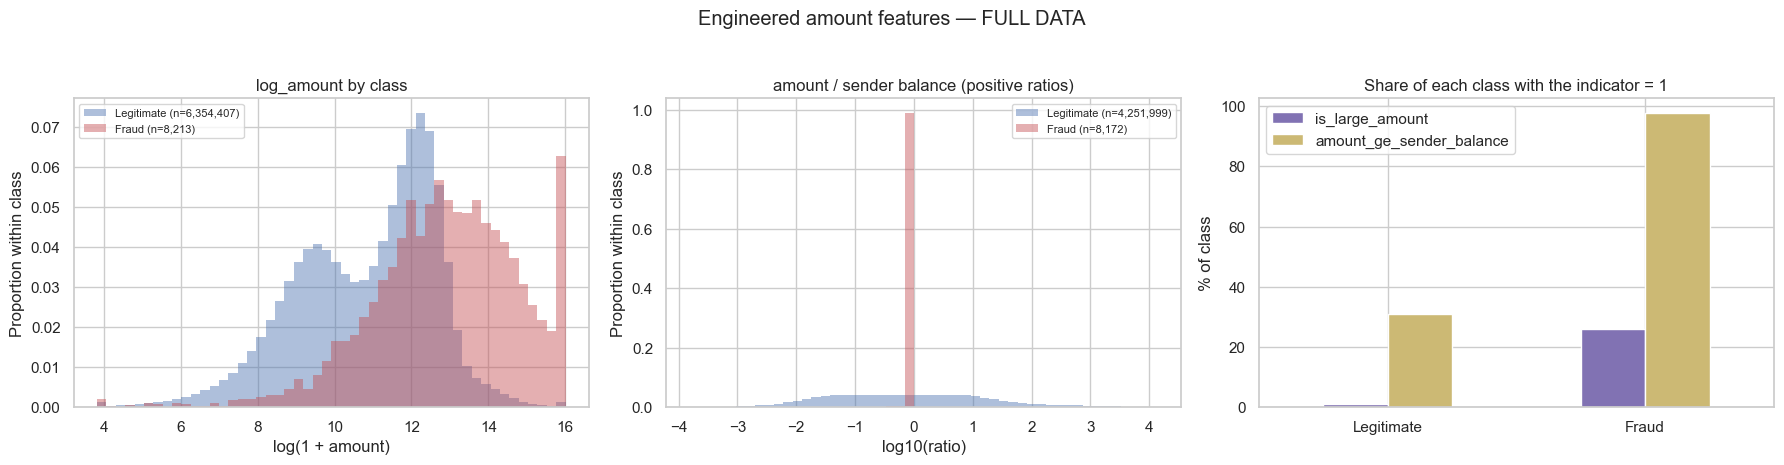

In [9]:
def safe_divide(numerator, denominator):
    """Element-wise division that returns NaN (not inf, not 0) where the denominator is not strictly positive."""
    num = np.asarray(numerator, dtype="float64")
    den = np.asarray(denominator, dtype="float64")
    out = np.full(num.shape, np.nan)
    np.divide(num, den, out=out, where=den > 0)
    return out


def create_amount_features(raw, params):
    """Amount features, including ratios to PRE-transaction balances (never to post-transaction balances)."""
    amt = raw["amount"].to_numpy(dtype="float64")
    old_o = raw["oldbalanceOrg"].to_numpy(dtype="float64")
    old_d = raw["oldbalanceDest"].to_numpy(dtype="float64")
    tol = params["tolerance"]
    return pd.DataFrame({
        "amount": amt,
        "log_amount": np.log1p(np.clip(amt, 0, None)).astype("float32"),
        "is_zero_amount": (amt == 0).astype("int8"),
        "is_large_amount": (amt >= params["large_amount_threshold"]).astype("int8"),
        "amount_to_sender_balance_ratio": safe_divide(amt, old_o).astype("float32"),
        "amount_ge_sender_balance": ((amt >= old_o - tol) & (old_o > 0)).astype("int8"),
        "sender_remaining_if_debited": (old_o - amt).astype("float32"),
        "amount_to_dest_balance_ratio": safe_divide(amt, old_d).astype("float32"),
    }, index=raw.index)


PARTS["amount"] = create_amount_features(X_raw, FE_PARAMS)
display(summarise_part(PARTS["amount"]))
print(f"Large-amount threshold (P{LARGE_AMOUNT_QUANTILE * 100:.0f} of training period): {FE_PARAMS['large_amount_threshold']:,.2f}")
print("Undefined ratios (denominator = 0 -> NaN):",
      f"sender ratio {int(PARTS['amount']['amount_to_sender_balance_ratio'].isna().sum()):,} rows,",
      f"destination ratio {int(PARTS['amount']['amount_to_dest_balance_ratio'].isna().sum()):,} rows")

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
plot_class_hist(axes[0], PARTS["amount"]["log_amount"].to_numpy(), y_arr, "log_amount by class", "log(1 + amount)")
plot_class_hist(axes[1], PARTS["amount"]["amount_to_sender_balance_ratio"].to_numpy(), y_arr, "amount / sender balance (positive ratios)", "log10(ratio)", transform="log10")
flag_rates = pd.DataFrame({"is_large_amount": PARTS["amount"]["is_large_amount"].to_numpy(), "amount_ge_sender_balance": PARTS["amount"]["amount_ge_sender_balance"].to_numpy(),
                           "y": y_arr})
rate_plot = pd.DataFrame({f: [100 * flag_rates.loc[(flag_rates[f] == 1) & (flag_rates.y == c)].shape[0] / max((flag_rates.y == c).sum(), 1) for c in (0, 1)]
                          for f in ("is_large_amount", "amount_ge_sender_balance")}, index=["Legitimate", "Fraud"])
rate_plot.plot(kind="bar", ax=axes[2], color=["#8172B3", "#CCB974"], rot=0)
axes[2].set(title="Share of each class with the indicator = 1", ylabel="% of class")
fig.suptitle("Engineered amount features — FULL DATA", y=1.03)
plt.tight_layout()
save_fig(fig, "p3_02_amount_features.png")
plt.show()
del flag_rates
CHECK["Amount features created"] = True

**Observation.** Compare the two class curves: separation on `log_amount` or on the amount/balance ratio suggests those features may be informative; overlap suggests they need help from other features. The right panel shows how common the two indicators are in each class. These are descriptive comparisons, not model results.

**Leakage note.** Ratios use only `amount` and **pre**-transaction balances. No feature here touches `newbalanceOrig` or `newbalanceDest`.

## SECTION 10 — Sender Balance Features

**Sender balance before** (`oldbalanceOrg`) describes the state *before* the money moves; **sender balance after** (`newbalanceOrig`) is a *result* of the transaction.

| Feature | Calculation | Prediction-time available? | Leakage status |
|---|---|---|---|
| `sender_balance_before` | `oldbalanceOrg` | Yes, if the balance snapshot precedes scoring | POTENTIAL_RISK (timing not documented) |
| `sender_balance_zero_before` | `oldbalanceOrg == 0` | same | POTENTIAL_RISK |
| `amount_to_sender_balance_ratio` (Section 9) | `amount / oldbalanceOrg` | same | POTENTIAL_RISK |
| `sender_balance_change` | `newbalanceOrig − oldbalanceOrg` | **No** | **UNSAFE** |
| `sender_balance_ratio` | `newbalanceOrig / oldbalanceOrg` | **No** | **UNSAFE** |
| `sender_balance_zero_after` | `newbalanceOrig == 0` | **No** | **UNSAFE** |
| `sender_balance_consistency` | `oldbalanceOrg − amount − newbalanceOrig` | **No** | **UNSAFE** |

**Why the UNSAFE features matter.** A live system scores a transaction *before* it completes, so `newbalanceOrig` does not exist yet. A model trained with it would look excellent offline and could not be deployed. The unsafe features are computed **only for the audit** (Section 20) and excluded from the final set.

## SECTION 11 — Destination Balance Features

The recipient side follows the same logic. Phase 2 also found that zero recipient balances may mean "untracked", so zero indicators are kept separate from the ratios.

| Feature | Calculation | Prediction-time available? | Leakage status |
|---|---|---|---|
| `dest_balance_before` | `oldbalanceDest` | Yes, if the snapshot precedes scoring | POTENTIAL_RISK |
| `dest_balance_zero_before` | `oldbalanceDest == 0` | same | POTENTIAL_RISK |
| `amount_to_dest_balance_ratio` (Section 9) | `amount / oldbalanceDest` (NaN if 0) | same | POTENTIAL_RISK |
| `dest_balance_change` | `newbalanceDest − oldbalanceDest` | **No** | **UNSAFE** |
| `dest_balance_zero_after` | `newbalanceDest == 0` | **No** | **UNSAFE** |
| `dest_balance_consistency` | `oldbalanceDest + amount − newbalanceDest` | **No** | **UNSAFE** |

**Sender balance features**

,dtype,nan_%,mean,median,min,max,zero_%
feature,,,,,,,
sender_balance_before,float32,0.0000,"833,883.3750","14,208.0000",0.0000,"59,585,040.0000",33.0438
sender_balance_zero_before,int8,0.0000,0.3304,0.0000,0.0000,1.0000,66.9562
sender_balance_change,float32,0.0000,"21,230.5762",0.0000,"-10,000,000.0000","1,915,267.8750",32.8330
sender_balance_ratio,float32,33.0438,24.7416,0.8047,0.0000,"548,910.8125",23.8987
sender_balance_zero_after,int8,0.0000,0.5673,1.0000,0.0000,1.0000,43.2692
sender_balance_consistency,float32,0.0000,"-201,092.6250","-68,677.2500","-92,445,520.0000",0.0100,14.9093


**Destination balance features**

,dtype,nan_%,mean,median,min,max,zero_%
feature,,,,,,,
dest_balance_before,float32,0.0000,"1,100,701.7500","132,705.6562",0.0000,"356,015,904.0000",42.5043
dest_balance_zero_before,int8,0.0000,0.4250,0.0000,0.0000,1.0000,57.4957
dest_balance_change,float32,0.0000,"124,294.7344",0.0000,"-13,060,826.0000","105,687,840.0000",36.4204
dest_balance_zero_after,int8,0.0000,0.3834,0.0000,0.0000,1.0000,61.6599
dest_balance_consistency,float32,0.0000,"55,567.2109","3,500.4900","-75,885,728.0000","13,191,234.0000",25.5547


Figure saved -> ..\reports\figures\p3_03_balance_features.png


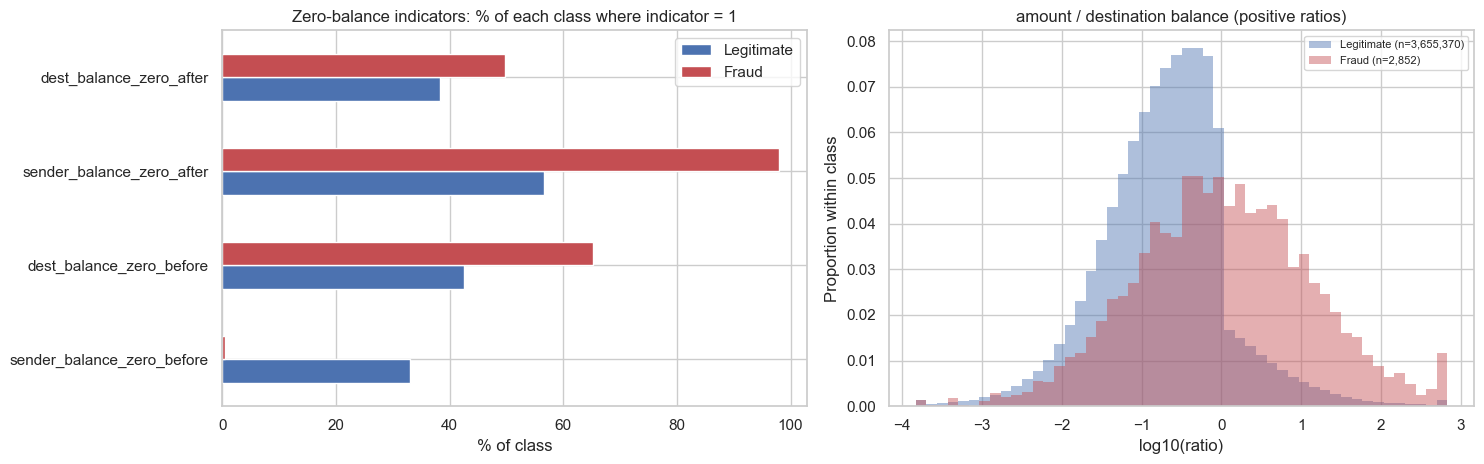

,Legitimate,Fraud,post-transaction (UNSAFE)
sender_balance_zero_before,33.0858,0.4992,False
dest_balance_zero_before,42.4750,65.1528,False
sender_balance_zero_after,56.6774,98.0519,True
dest_balance_zero_after,38.3252,49.8113,True


In [10]:
def create_balance_features(raw, params, include_post_transaction=True):
    """
    Balance features for sender and destination.
    Pre-transaction features are always created. Post-transaction (UNSAFE) features are created only
    when include_post_transaction=True (used for the audit; a live scoring service must call it with False).
    """
    old_o = raw["oldbalanceOrg"].to_numpy(dtype="float64")
    old_d = raw["oldbalanceDest"].to_numpy(dtype="float64")
    cols = {
        "sender_balance_before": old_o.astype("float32"),
        "sender_balance_zero_before": (old_o == 0).astype("int8"),
        "dest_balance_before": old_d.astype("float32"),
        "dest_balance_zero_before": (old_d == 0).astype("int8"),
    }
    if include_post_transaction:
        amt = raw["amount"].to_numpy(dtype="float64")
        new_o = raw["newbalanceOrig"].to_numpy(dtype="float64")
        new_d = raw["newbalanceDest"].to_numpy(dtype="float64")
        cols.update({
            "sender_balance_change": (new_o - old_o).astype("float32"),
            "sender_balance_ratio": safe_divide(new_o, old_o).astype("float32"),
            "sender_balance_zero_after": (new_o == 0).astype("int8"),
            "sender_balance_consistency": (old_o - amt - new_o).astype("float32"),
            "dest_balance_change": (new_d - old_d).astype("float32"),
            "dest_balance_zero_after": (new_d == 0).astype("int8"),
            "dest_balance_consistency": (old_d + amt - new_d).astype("float32"),
        })
    return pd.DataFrame(cols, index=raw.index)


PARTS["balance"] = create_balance_features(X_raw, FE_PARAMS, include_post_transaction=True)
sender_cols = [c for c in PARTS["balance"].columns if c.startswith("sender_")]
dest_cols = [c for c in PARTS["balance"].columns if c.startswith("dest_")]
md("**Sender balance features**")
display(summarise_part(PARTS["balance"][sender_cols]))
md("**Destination balance features**")
display(summarise_part(PARTS["balance"][dest_cols]))

zero_cols = [c for c in PARTS["balance"].columns if "zero" in c]
zr = pd.DataFrame({c: [100 * ((PARTS["balance"][c].to_numpy() == 1) & (y_arr == k)).sum() / max((y_arr == k).sum(), 1) for k in (0, 1)] for c in zero_cols},
                  index=["Legitimate", "Fraud"]).T
fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
zr.plot(kind="barh", ax=axes[0], color=[COLORS[0], COLORS[1]])
axes[0].set(title="Zero-balance indicators: % of each class where indicator = 1", xlabel="% of class")
plot_class_hist(axes[1], PARTS["amount"]["amount_to_dest_balance_ratio"].to_numpy(), y_arr, "amount / destination balance (positive ratios)", "log10(ratio)", transform="log10")
plt.tight_layout()
save_fig(fig, "p3_03_balance_features.png")
plt.show()
display(zr.assign(**{"post-transaction (UNSAFE)": [("after" in c or "consistency" in c or "change" in c) for c in zr.index]}))
CHECK["Balance features reviewed"] = True

**Observation.** The zero-indicators are compared between classes. Pay particular attention to the ones marked *post-transaction (UNSAFE)*: if they separate the classes very strongly, that is exactly the leakage warning — the pattern exists **because** of how the transaction was recorded, and cannot be seen before it happens.

## SECTION 12 — Account Behaviour Features (past information only)

`nameOrig` and `nameDest` are identifiers with millions of unique values (Phase 2). They are **not** encoded. Instead they act as **keys** to summarise an account's *earlier* behaviour.

**Sender features** (prefix `sender_`): `prev_txn_count`, `prev_total_amount`, `prev_mean_amount`, `prev_max_amount`, `prev_unique_counterparties` (distinct destinations already used).
**Destination features** (prefix `dest_`): the same five, where the counterparties are distinct senders.
**Pair features:** `is_new_destination_for_sender` and `amount_vs_*_hist_mean` (current amount relative to the account's own earlier average).

### How the "past only" rule is guaranteed
1. Accounts are converted to integer codes and events kept in **event order**.
2. Within each account, a feature for event *i* is computed from cumulative sums over events **before** *i* (the current event is excluded).
3. Section 21 proves it twice: (a) a **prefix-invariance test** (removing all later rows changes nothing), and (b) an independent **streaming reference implementation** that only ever sees one event at a time reproduces the batch numbers.

**Undefined values.** For an account with no history, means/maxima are `NaN` ("no history") — **not** 0 — while counts and totals are legitimately `0`.

**Prediction-time availability:** yes, *if the live system keeps per-account state* (counters and a recent-events buffer). This is exactly what Spark stateful streaming provides later.

**Sparse history warning (from Phase 2):** PaySim senders almost never repeat. Sender-side history features may therefore be almost constant in this dataset; the near-zero-variance review (Section 19) decides objectively whether they are kept. Their *definitions* remain valid for real data and for the destination side.

In [11]:
def factorize_accounts(series, name):
    codes, _ = pd.factorize(series)
    if (codes < 0).any():
        raise ValueError(f"Missing account identifiers in '{name}' - cannot build account history.")
    return codes.astype(np.int64)


def past_window_features(codes, step, amount, new_pair, params, prefix):
    """
    PAST-ONLY account features for every event (vectorised, exact).

    For event i of an account, only earlier events of the same account (earlier in event order) are used.
    Windows are measured in steps: an earlier event j is 'inside window W' when step_j > step_i - W.
    """
    n = len(codes)
    windows = params["windows"]
    max_w = max(windows)
    order = np.argsort(codes, kind="stable")              # groups by account, keeps event order inside each account
    c = codes[order]
    s = step[order].astype(np.int64)
    a = amount[order].astype(np.float64)
    f = new_pair[order].astype(np.int64)
    pos = np.arange(n, dtype=np.int64)

    starts = np.flatnonzero(np.r_[True, c[1:] != c[:-1]])
    sizes = np.diff(np.r_[starts, n])
    first = np.repeat(starts, sizes)                       # index of the first event of the event's account
    cs = np.concatenate(([0.0], np.cumsum(a)))             # prefix sums of amounts
    fcs = np.concatenate(([0], np.cumsum(f)))              # prefix sums of "first-ever pair" flags

    prev_count = pos - first
    prev_total = cs[pos] - cs[first]
    prev_mean = np.full(n, np.nan)
    has = prev_count > 0
    prev_mean[has] = prev_total[has] / prev_count[has]
    prev_unique = fcs[pos] - fcs[first]

    # running maximum of EARLIER amounts (only accounts with >1 event need computing)
    prev_max = np.full(n, np.nan)
    multi = np.flatnonzero(np.repeat(sizes, sizes) > 1)
    if len(multi):
        cm = pd.Series(a[multi]).groupby(c[multi]).cummax().to_numpy()
        # shift by one inside the account: value of the previous multi-row, valid only if it is in the same account
        shifted = np.empty_like(cm)
        shifted[1:] = cm[:-1]
        same_acct = np.r_[False, c[multi][1:] == c[multi][:-1]]
        shifted[~same_acct] = np.nan
        prev_max[multi] = shifted

    hours_since = np.full(n, np.nan)
    m = pos > first
    hours_since[m] = s[pos[m]] - s[pos[m] - 1]

    out = {f"{prefix}_prev_txn_count": prev_count, f"{prefix}_prev_total_amount": prev_total, f"{prefix}_prev_mean_amount": prev_mean,
           f"{prefix}_prev_max_amount": prev_max, f"{prefix}_prev_unique_counterparties": prev_unique,
           f"{prefix}_hours_since_prev_txn": hours_since}

    big_m = int(s.max()) + max_w + 2
    key = c * big_m + s + max_w                            # sorted ascending (account, then step)
    for w in windows:
        q = c * big_m + s + (max_w - w) + 1                # first key with step_j >= step_i - w + 1
        lb = np.searchsorted(key, q, side="left")          # first event inside the window
        out[f"{prefix}_txn_count_last_{w}h"] = pos - lb    # events lb .. i-1  (excludes the current event)
        if w in params["sum_windows"]:
            out[f"{prefix}_amount_sum_last_{w}h"] = cs[pos] - cs[lb]
        if w in params["newcp_windows"]:
            out[f"{prefix}_new_counterparties_last_{w}h"] = fcs[pos] - fcs[lb]

    result = {}
    for name, values in out.items():
        restored = np.empty(n, dtype=np.float64)
        restored[order] = values                            # back to event order
        if "count" in name or "counterparties" in name:
            result[name] = restored.astype("int32")
        else:
            result[name] = restored.astype("float32")
    return pd.DataFrame(result)


def build_account_state(raw, params):
    """Encode accounts once, flag first-ever (sender, destination) pairs, and compute all past-only account/velocity columns."""
    s_codes = factorize_accounts(raw["nameOrig"], "nameOrig")
    d_codes = factorize_accounts(raw["nameDest"], "nameDest")
    pair = s_codes * (int(d_codes.max()) + 1) + d_codes
    new_pair = ~pd.Series(pair).duplicated(keep="first").to_numpy()      # True at the first ever occurrence of a pair, in event order
    step = raw["step"].to_numpy()
    amount = raw["amount"].to_numpy()
    sender = past_window_features(s_codes, step, amount, new_pair, params, "sender")
    dest = past_window_features(d_codes, step, amount, new_pair, params, "dest")
    sender.index = raw.index
    dest.index = raw.index
    return {"new_pair": new_pair, "sender": sender, "dest": dest}


HISTORY_SUFFIXES = ["prev_txn_count", "prev_total_amount", "prev_mean_amount", "prev_max_amount", "prev_unique_counterparties"]


def create_account_features(raw, params, state):
    """Behavioural history of the sender and destination accounts (earlier events only)."""
    s_cols = [f"sender_{k}" for k in HISTORY_SUFFIXES]
    d_cols = [f"dest_{k}" for k in HISTORY_SUFFIXES]
    out = pd.concat([state["sender"][s_cols], state["dest"][d_cols]], axis=1)
    out["is_new_destination_for_sender"] = state["new_pair"].astype("int8")
    amt = raw["amount"].to_numpy(dtype="float64")
    out["amount_vs_sender_hist_mean"] = safe_divide(amt, state["sender"]["sender_prev_mean_amount"].to_numpy()).astype("float32")
    out["amount_vs_dest_hist_mean"] = safe_divide(amt, state["dest"]["dest_prev_mean_amount"].to_numpy()).astype("float32")
    return out


t0 = time.time()
STATE = build_account_state(X_raw, FE_PARAMS)
PARTS["account"] = create_account_features(X_raw, FE_PARAMS, STATE)
print(f"Account state + behaviour features created in {time.time() - t0:.1f}s")
display(summarise_part(PARTS["account"]))

s_rep = pct(int((PARTS["account"]["sender_prev_txn_count"] > 0).sum()), len(X_raw))
d_rep = pct(int((PARTS["account"]["dest_prev_txn_count"] > 0).sum()), len(X_raw))
print(f"\nTransactions whose SENDER has earlier history     : {s_rep:.3f}%")
print(f"Transactions whose DESTINATION has earlier history: {d_rep:.3f}%")
print("If the sender percentage is tiny, sender-history features carry almost no information in PaySim (see Section 19).")
CHECK["Account behaviour features reviewed"] = True

Account state + behaviour features created in 44.9s


,dtype,nan_%,mean,median,min,max,zero_%
feature,,,,,,,
sender_prev_txn_count,int32,0.0000,0.0015,0.0000,0.0000,2.0000,99.8536
sender_prev_total_amount,float32,0.0000,260.7062,0.0000,0.0000,"46,211,920.0000",99.8536
sender_prev_mean_amount,float32,99.8536,"177,898.9844","71,604.7812",0.5200,"46,211,920.0000",0.0000
sender_prev_max_amount,float32,99.8536,"178,024.9531","71,750.9688",0.5200,"46,211,920.0000",0.0000
sender_prev_unique_counterparties,int32,0.0000,0.0015,0.0000,0.0000,2.0000,99.8536
dest_prev_txn_count,int32,0.0000,5.0961,1.0000,0.0000,112.0000,42.7868
dest_prev_total_amount,float32,0.0000,"1,360,496.8750","228,976.2188",0.0000,"357,277,440.0000",42.7868
dest_prev_mean_amount,float32,42.7868,"254,398.1406","201,924.4688",0.0000,"39,920,572.0000",0.0000
dest_prev_max_amount,float32,42.7868,"722,436.5000","412,740.6250",0.0000,"92,445,520.0000",0.0000



Transactions whose SENDER has earlier history     : 0.146%
Transactions whose DESTINATION has earlier history: 57.213%
If the sender percentage is tiny, sender-history features carry almost no information in PaySim (see Section 19).


**Interpretation.** The two percentages above quantify how much history actually exists. This connects directly to the Phase 2 finding about repeated accounts and is the reason the variance review in Section 19 is applied objectively instead of assuming these features are useful.

## SECTION 13 — Transaction Velocity Features (past information only)

Velocity = *how fast* an account has recently been active. Windows are measured in **steps (hours)**:

| Window | Meaning |
|---|---|
| 1 step | the **same step** (earlier events of the same simulated hour only) |
| 24 steps | previous simulated day |
| 168 steps | previous simulated week |

For sender (`sender_`) and destination (`dest_`):

| Feature | Meaning |
|---|---|
| `*_txn_count_last_{1,24,168}h` | earlier transactions in the window |
| `*_amount_sum_last_{24,168}h` | total earlier amount in the window |
| `*_new_counterparties_last_{24,168}h` | earlier transactions in the window in which the account met a counterparty for the **first ever** time |
| `*_hours_since_prev_txn` | time since the previous transaction (NaN if none) |

**About "unique recent destinations/senders".** An exact distinct-count inside a sliding window needs expensive 2-D counting. The *first-ever-pair* count above is **exact, cheap, and streaming-friendly** (a Spark state only needs a set of seen pairs) and captures the same fraud idea: many *new* counterparties in a short time. This is a deliberate, documented simplification.

All windows exclude the current event and any later event → **past only**. Available at prediction time if per-account state (a buffer of the last 168 steps) is kept.

,dtype,nan_%,mean,median,min,max,zero_%
feature,,,,,,,
sender_hours_since_prev_txn,float32,99.8536,158.3126,139.0000,0.0000,704.0000,0.0007
sender_txn_count_last_1h,int32,0.0000,0.0000,0.0000,0.0000,1.0000,99.9993
sender_txn_count_last_24h,int32,0.0000,0.0002,0.0000,0.0000,1.0000,99.9828
sender_txn_count_last_168h,int32,0.0000,0.0009,0.0000,0.0000,2.0000,99.9126
sender_amount_sum_last_24h,float32,0.0000,40.9665,0.0000,0.0000,"46,211,920.0000",99.9828
sender_amount_sum_last_168h,float32,0.0000,162.6804,0.0000,0.0000,"46,211,920.0000",99.9126
sender_new_counterparties_last_24h,int32,0.0000,0.0002,0.0000,0.0000,1.0000,99.9828
sender_new_counterparties_last_168h,int32,0.0000,0.0009,0.0000,0.0000,2.0000,99.9126
dest_hours_since_prev_txn,float32,42.7868,30.3222,15.0000,0.0000,681.0000,4.9733


Figure saved -> ..\reports\figures\p3_04_velocity_features.png


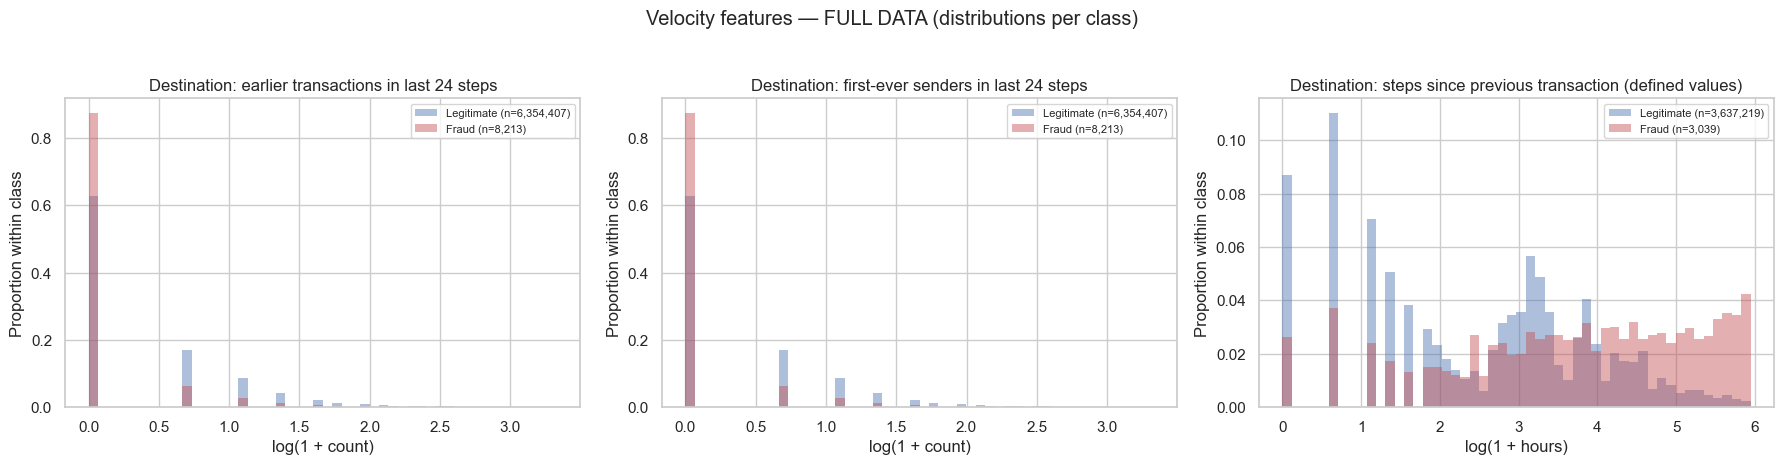

6906

In [12]:
def create_velocity_features(raw, params, state):
    """Recent-activity features (past events inside step windows) for sender and destination."""
    vel_suffixes = (["hours_since_prev_txn"] + [f"txn_count_last_{w}h" for w in params["windows"]]
                    + [f"amount_sum_last_{w}h" for w in params["sum_windows"]] + [f"new_counterparties_last_{w}h" for w in params["newcp_windows"]])
    return pd.concat([state["sender"][[f"sender_{k}" for k in vel_suffixes]], state["dest"][[f"dest_{k}" for k in vel_suffixes]]], axis=1)


PARTS["velocity"] = create_velocity_features(X_raw, FE_PARAMS, STATE)
display(summarise_part(PARTS["velocity"]))

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
plot_class_hist(axes[0], PARTS["velocity"]["dest_txn_count_last_24h"].to_numpy(), y_arr, "Destination: earlier transactions in last 24 steps", "log(1 + count)", transform="log1p")
plot_class_hist(axes[1], PARTS["velocity"]["dest_new_counterparties_last_24h"].to_numpy(), y_arr, "Destination: first-ever senders in last 24 steps", "log(1 + count)", transform="log1p")
plot_class_hist(axes[2], PARTS["velocity"]["dest_hours_since_prev_txn"].to_numpy(), y_arr, "Destination: steps since previous transaction (defined values)", "log(1 + hours)", transform="log1p")
fig.suptitle("Velocity features — FULL DATA (distributions per class)", y=1.03)
plt.tight_layout()
save_fig(fig, "p3_04_velocity_features.png")
plt.show()
CHECK["Velocity features created where safe"] = True
del STATE
gc.collect()

**Observation.** If the two class curves differ, recent destination activity may help separate fraud; if they coincide, the feature adds little on its own. Features with almost no variation (typically the sender-side ones in PaySim) are dealt with objectively in Section 19.

## SECTION 14 — Transaction Type Encoding

`type` is a **nominal** category. Encoding it as PAYMENT=1, TRANSFER=2, CASH_OUT=3 … would tell a model that CASH_OUT is "greater than" PAYMENT, which is false.

**Strategy: one-hot encoding** with a category list **fitted on the training period and frozen**:
* five small `int8` columns (`type_PAYMENT`, `type_TRANSFER`, …);
* no category is dropped (tree models do not need a reference level);
* a transaction type that never appeared in the training period gets **all zeros** (safe behaviour for live data; counted below);
* identical logic runs in streaming, because the category list is stored in the metadata.

Alternative for Phase 4 (not used now): pandas `category` dtype with XGBoost's native categorical support.

In [13]:
def encode_transaction_type(raw, params):
    """One-hot encode `type` using the frozen category list."""
    t = raw["type"]
    return pd.DataFrame({f"type_{cat}": (t == cat).to_numpy().astype("int8") for cat in params["type_categories"]}, index=raw.index)


print("Transaction types present in the data:", sorted(X_raw["type"].astype(str).unique().tolist()))
print("Categories used for encoding (from training period):", FE_PARAMS["type_categories"])
PARTS["type"] = encode_transaction_type(X_raw, FE_PARAMS)
unseen = int((PARTS["type"].sum(axis=1) == 0).sum())
print(f"Rows whose type is NOT in the frozen category list (all-zero encoding): {unseen:,}")
display(summarise_part(PARTS["type"])[["dtype", "mean", "zero_%"]].rename(columns={"mean": "share of rows"}))
CHECK["Transaction type encoded"] = True

Transaction types present in the data: ['CASH_IN', 'CASH_OUT', 'DEBIT', 'PAYMENT', 'TRANSFER']
Categories used for encoding (from training period): ['CASH_IN', 'CASH_OUT', 'DEBIT', 'PAYMENT', 'TRANSFER']
Rows whose type is NOT in the frozen category list (all-zero encoding): 0


,dtype,share of rows,zero_%
feature,,,
type_CASH_IN,int8,0.2199,78.0077
type_CASH_OUT,int8,0.3517,64.8337
type_DEBIT,int8,0.0065,99.3488
type_PAYMENT,int8,0.3381,66.1854
type_TRANSFER,int8,0.0838,91.6244


**Explanation.** Each row has exactly one `1` among the type columns (or none, for a never-seen type). No numeric ordering is implied.

## SECTION 15 — `isFlaggedFraud` Analysis

`isFlaggedFraud` is an **existing rule-based flag** of the simulated system. The decision must weigh: *prediction-time availability*, *usefulness*, *redundancy* and *leakage risk*. The evidence below is computed from the data; the label is used here **only to describe** how the flag relates to fraud, not to select features.

In [14]:
def analyze_flag(raw, y_values):
    """Descriptive evidence about the existing rule flag."""
    flag = raw[FLAG_COL].to_numpy() == 1
    n_flag = int(flag.sum())
    fraud = y_values == 1
    ev = {"rows": len(raw), "flagged_rows": n_flag, "flagged_pct_of_rows": pct(n_flag, len(raw)),
          "flagged_and_fraud": int((flag & fraud).sum()), "fraud_not_flagged": int((~flag & fraud).sum()),
          "flagged_not_fraud": int((flag & ~fraud).sum()),
          "fraud_coverage_pct": pct(int((flag & fraud).sum()), int(fraud.sum()))}
    if n_flag:
        types = raw.loc[flag, "type"].astype(str)
        ev["flagged_types"] = types.value_counts().to_dict()
        min_amt = float(raw.loc[flag, "amount"].min())
        same = (raw["type"].astype(str).to_numpy() == types.mode().iloc[0]) & (raw["amount"].to_numpy() >= min_amt)
        ev["min_flagged_amount"] = min_amt
        ev["share_of_similar_rows_flagged_pct"] = pct(int((same & flag).sum()), int(same.sum()))
    return ev


FLAG_DECISION = {"retain": False, "action": "Exclude", "reasons": []}
if FLAG_COL in X_raw.columns:
    fev = analyze_flag(X_raw, y_arr)
    display(pd.DataFrame({"Flagged": [1, 1, 0, 0], "Actual fraud": [1, 0, 1, 0],
                          "Count": [fev["flagged_and_fraud"], fev["flagged_not_fraud"], fev["fraud_not_flagged"], fev["rows"] - fev["flagged_rows"] - fev["fraud_not_flagged"]]}))
    for k, v in fev.items():
        print(f"  {k:<34}: {v}")
    reasons = ["Prediction-time availability: the moment the rule sets the flag (before or after the score) is not documented -> cannot be guaranteed."]
    rare = fev["flagged_pct_of_rows"] < 0.01
    low_cov = fev["fraud_coverage_pct"] < 1.0
    if rare:
        reasons.append(f"Usefulness/variance: only {fev['flagged_rows']:,} rows ({fev['flagged_pct_of_rows']:.5f}%) are flagged -> near-zero variance.")
    if low_cov:
        reasons.append(f"Usefulness: the flag covers only {fev['fraud_coverage_pct']:.4f}% of all fraud.")
    if fev["flagged_rows"] and fev.get("share_of_similar_rows_flagged_pct", 100) < 50:
        reasons.append("Redundancy: flagged rows are a tiny subset of otherwise similar transactions -> the flag adds little beyond type and amount.")
    reasons.append("Leakage risk: a model given the rule's output may simply reproduce the rule instead of learning fraud patterns.")
    FLAG_DECISION.update(reasons=reasons, evidence=fev)
    if not (rare or low_cov):
        FLAG_DECISION.update(retain=True, action="Retain as POTENTIAL_RISK (test with/without in Phase 4)")
        FE_PARAMS["retain_flag_feature"] = True
    else:
        FLAG_DECISION["action"] = "Exclude"
else:
    print(f"Column '{FLAG_COL}' not found -> no rule flag to evaluate.")
    FLAG_DECISION.update(reasons=["Column not present in the CSV."], evidence={})

print("\nDECISION:", FLAG_DECISION["action"])
for r in FLAG_DECISION["reasons"]:
    print("  -", r)
NON_FRAME_SPECS[FLAG_COL]["default_action"] = FLAG_DECISION["action"]
if FLAG_DECISION["retain"]:
    spec("is_flagged_by_rule", "Rule-derived flag", "Existing rule-based flag (raw isFlaggedFraud).", "isFlaggedFraud", "Needs investigation", "POTENTIAL_RISK",
         "Rule output with undocumented timing.", "Keep (ablate in Phase 4)")
    PARTS["flag"] = pd.DataFrame({"is_flagged_by_rule": X_raw[FLAG_COL].to_numpy().astype("int8")}, index=X_raw.index)
CHECK["isFlaggedFraud evaluated"] = True

,Flagged,Actual fraud,Count
0,1,1,16
1,1,0,0
2,0,1,8197
3,0,0,6354407


  rows                              : 6362620
  flagged_rows                      : 16
  flagged_pct_of_rows               : 0.00025146873457789404
  flagged_and_fraud                 : 16
  fraud_not_flagged                 : 8197
  flagged_not_fraud                 : 0
  fraud_coverage_pct                : 0.19481310118105444
  flagged_types                     : {'TRANSFER': 16}
  min_flagged_amount                : 353874.22
  share_of_similar_rows_flagged_pct : 0.0049209722610944855

DECISION: Exclude
  - Prediction-time availability: the moment the rule sets the flag (before or after the score) is not documented -> cannot be guaranteed.
  - Usefulness/variance: only 16 rows (0.00025%) are flagged -> near-zero variance.
  - Usefulness: the flag covers only 0.1948% of all fraud.
  - Redundancy: flagged rows are a tiny subset of otherwise similar transactions -> the flag adds little beyond type and amount.
  - Leakage risk: a model given the rule's output may simply reproduce the ru

**Decision explained.** The rule is not automatically kept or removed: it is judged on availability, usefulness, redundancy and leakage using the numbers printed above. The decision and its reasons are stored in the feature metadata so it can be revisited (e.g. as a Phase 4 ablation experiment).

### Assembling the feature table
The next cell concatenates all feature groups into one DataFrame `feat`, verifies that every column is registered in the Section 7 plan, and defines `run_feature_engineering()` — the **single reusable entry point** that applies the same definitions to any set of transactions (historical batch today, replayed/live events later).

In [15]:
def create_flag_feature(raw):
    return pd.DataFrame({"is_flagged_by_rule": raw[FLAG_COL].to_numpy().astype("int8")}, index=raw.index)


def run_feature_engineering(raw, params, include_post_transaction=True):
    """
    Apply ALL feature definitions to a set of transactions in event order.
    `raw` must NOT contain the label. Returns one DataFrame of engineered features (same index as `raw`).
    Use include_post_transaction=False for anything that will be served in production.
    """
    assert TARGET not in raw.columns, "The label must never be passed to feature engineering."
    assert raw["step"].is_monotonic_increasing, "Transactions must be in chronological (event) order."
    state = build_account_state(raw, params)
    parts = [create_temporal_features(raw, params), create_amount_features(raw, params),
             create_balance_features(raw, params, include_post_transaction), create_account_features(raw, params, state),
             create_velocity_features(raw, params, state), encode_transaction_type(raw, params)]
    if params.get("retain_flag_feature"):
        parts.append(create_flag_feature(raw))
    return pd.concat(parts, axis=1)


feat = pd.concat(list(PARTS.values()), axis=1)
del PARTS
gc.collect()

unregistered = [c for c in feat.columns if c not in FEATURE_SPECS]
missing_from_frame = [c for c in FEATURE_SPECS if c not in feat.columns]
print(f"Engineered feature columns: {feat.shape[1]} | rows: {len(feat):,} | memory: {feat.memory_usage(deep=True).sum() / 1024 ** 2:,.0f} MB")
assert not unregistered, f"Columns without registry entry: {unregistered}"
if missing_from_frame:
    print("Registry entries without a column (ignored):", missing_from_frame)
    for k in missing_from_frame:
        FEATURE_SPECS.pop(k, None)
assert TARGET not in feat.columns
print("Every engineered column is registered; the label is not among the features.")

Engineered feature columns: 58 | rows: 6,362,620 | memory: 1,147 MB
Every engineered column is registered; the label is not among the features.


## SECTION 16 — Missing Value Handling

Some engineered values are **undefined by nature**, not "missing data":

| Situation | Result | Why not 0? |
|---|---|---|
| Ratio whose denominator is 0 (e.g. `amount / oldbalanceOrg` when the balance is 0) | `NaN` | 0 would claim "amount is zero relative to balance", which is false; the zero balance is captured by a separate indicator |
| Mean/max of earlier amounts for an account with **no history** | `NaN` | 0 would mean "the account always sent nothing" |
| Time since previous transaction when there is none | `NaN` | 0 would mean "just transacted" |
| Counts / totals with no history | `0` | Genuinely zero earlier transactions |

**Policy.** `NaN` is **kept** (XGBoost learns a default direction for missing values). No blanket `fillna(0)`. If a Phase 4 model family needs imputation, the imputer must be **fitted on the training period only** and stored with the model. Any `NaN` in a feature *not* listed as "by design" would be a bug and is reported.

In [16]:
NAN_BY_DESIGN = [c for c in feat.columns if any(k in c for k in ("ratio", "prev_mean_amount", "prev_max_amount", "hours_since_prev_txn", "amount_vs_"))]

nan_tbl = pd.DataFrame({"nan_count": feat.isna().sum(), "nan_pct": 100 * feat.isna().mean()})
nan_tbl["by_design"] = nan_tbl.index.isin(NAN_BY_DESIGN)
nan_tbl["treatment"] = np.where(nan_tbl["nan_count"] == 0, "no missing values",
                                np.where(nan_tbl["by_design"], "kept as NaN (undefined by design)", "UNEXPECTED - investigate"))
display(nan_tbl[nan_tbl["nan_count"] > 0].sort_values("nan_pct", ascending=False))
unexpected_nan = nan_tbl[(nan_tbl["nan_count"] > 0) & (~nan_tbl["by_design"])].index.tolist()
print("Features with NaN:", int((nan_tbl["nan_count"] > 0).sum()), "| unexpected NaN features:", unexpected_nan if unexpected_nan else "none")
assert not unexpected_nan, "Unexpected NaN values in engineered features"
CHECK["Missing values handled"] = True

,nan_count,nan_pct,by_design,treatment
sender_prev_mean_amount,6353307,99.8536,True,kept as NaN (undefined by design)
sender_prev_max_amount,6353307,99.8536,True,kept as NaN (undefined by design)
amount_vs_sender_hist_mean,6353307,99.8536,True,kept as NaN (undefined by design)
sender_hours_since_prev_txn,6353307,99.8536,True,kept as NaN (undefined by design)
amount_vs_dest_hist_mean,2722364,42.7868,True,kept as NaN (undefined by design)
dest_prev_mean_amount,2722362,42.7868,True,kept as NaN (undefined by design)
dest_prev_max_amount,2722362,42.7868,True,kept as NaN (undefined by design)
dest_hours_since_prev_txn,2722362,42.7868,True,kept as NaN (undefined by design)
amount_to_dest_balance_ratio,2704388,42.5043,True,kept as NaN (undefined by design)
amount_to_sender_balance_ratio,2102449,33.0438,True,kept as NaN (undefined by design)


Features with NaN: 11 | unexpected NaN features: none


## SECTION 17 — Infinite Value Handling

Naive division by a zero balance would produce `inf`. All ratios use `safe_divide`, which returns `NaN` instead. The cell below (a) shows how many rows *would* have produced `inf`, and (b) verifies that **no infinite value** exists in any engineered feature.

In [17]:
zero_old_o = int(((X_raw["oldbalanceOrg"] == 0) & (X_raw["amount"] > 0)).sum())
zero_old_d = int(((X_raw["oldbalanceDest"] == 0) & (X_raw["amount"] > 0)).sum())
print(f"Rows where a naive amount/oldbalanceOrg would be inf : {zero_old_o:,}")
print(f"Rows where a naive amount/oldbalanceDest would be inf: {zero_old_d:,}")

float_cols = [c for c in feat.columns if pd.api.types.is_float_dtype(feat[c])]
inf_counts = {c: int(np.isinf(feat[c].to_numpy()).sum()) for c in float_cols}
bad_inf = {k: v for k, v in inf_counts.items() if v}
print(f"Float features checked: {len(float_cols)} | features containing inf: {bad_inf if bad_inf else 'none'}")
assert not bad_inf, "Infinite values found in engineered features"
CHECK["Infinite values checked"] = True

Rows where a naive amount/oldbalanceOrg would be inf : 2,102,433
Rows where a naive amount/oldbalanceDest would be inf: 2,704,382
Float features checked: 28 | features containing inf: none


## SECTION 18 — Outlier Review

**Fraud transactions can naturally be unusual, so nothing is deleted or clipped.** The review quantifies extreme values of the main continuous engineered features (1.5×IQR rule on defined values) and how they relate to the classes; the class split is descriptive only.

**Treatments already in place (no rows removed):**
* `log_amount` compresses the tail;
* `is_large_amount` marks the tail explicitly (threshold from the training period);
* `NaN` (not a huge number) marks undefined ratios;
* tree models such as XGBoost are insensitive to monotone scaling of features.

,defined_rows,median,P99,P99.9,max,iqr_outlier_%,outlier_%_among_fraud,outlier_%_among_legit
feature,,,,,,,,
amount,6362620,"74,871.9400","1,615,979.4716","8,956,797.6770","92,445,516.6400",5.3135,46.9256,5.2597
amount_to_sender_balance_ratio,4260171,0.7408,"1,675.1712","14,164.5118","3,925,475.5000",15.9179,0.0245,15.9485
amount_to_dest_balance_ratio,3658232,0.2112,30.6107,675.9884,"5,542,638.5000",9.4130,45.6324,9.3846
sender_remaining_if_debited,6362620,"-14,619.1250","15,862,297.5600","26,672,742.0020","49,585,040.0000",20.2437,1.8629,20.2674
dest_amount_sum_last_24h,6362620,0.0000,"4,405,929.9500","14,572,796.5780","292,068,224.0000",13.5273,3.9328,13.5397
dest_txn_count_last_24h,6362620,0.0000,13.0000,27.0000,92.0000,11.7695,3.4336,11.7802
dest_prev_total_amount,6362620,"228,976.2266","12,235,243.8900","30,000,000.0000","357,277,440.0000",10.2726,4.7729,10.2797


Figure saved -> ..\reports\figures\p3_05_outlier_review.png


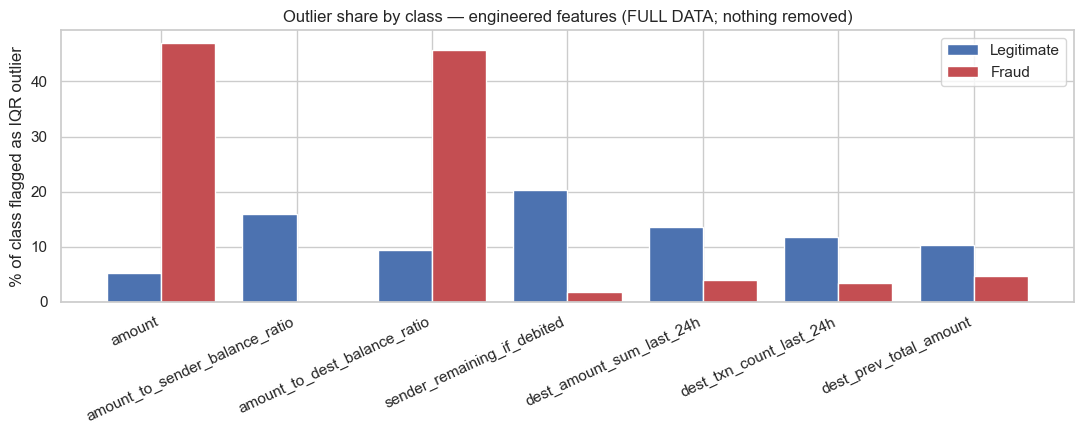

Decision: outliers are preserved. No clipping, winsorising or deletion is applied to the stored features.


In [18]:
def outlier_review(frame, cols, y_values):
    rows = []
    fraud = y_values == 1
    for c in cols:
        v = frame[c].to_numpy(dtype="float64")
        ok = np.isfinite(v)
        if ok.sum() == 0:
            continue
        q1, q50, q3, q99, q999 = np.percentile(v[ok], [25, 50, 75, 99, 99.9])
        iqr = q3 - q1
        mask = ok & ((v < q1 - 1.5 * iqr) | (v > q3 + 1.5 * iqr))
        rows.append({"feature": c, "defined_rows": int(ok.sum()), "median": q50, "P99": q99, "P99.9": q999, "max": v[ok].max(),
                     "iqr_outlier_%": pct(int(mask.sum()), int(ok.sum())),
                     "outlier_%_among_fraud": pct(int((mask & fraud).sum()), int((ok & fraud).sum())),
                     "outlier_%_among_legit": pct(int((mask & ~fraud).sum()), int((ok & ~fraud).sum()))})
    return pd.DataFrame(rows).set_index("feature")


OUT_COLS = [c for c in ["amount", "amount_to_sender_balance_ratio", "amount_to_dest_balance_ratio", "sender_remaining_if_debited",
                        "dest_amount_sum_last_24h", "dest_txn_count_last_24h", "dest_prev_total_amount"] if c in feat.columns]
outlier_tbl = outlier_review(feat, OUT_COLS, y_arr)
display(outlier_tbl)

fig, ax = plt.subplots(figsize=(11, 4.5))
x = np.arange(len(outlier_tbl))
ax.bar(x - 0.2, outlier_tbl["outlier_%_among_legit"], 0.4, color=COLORS[0], label="Legitimate")
ax.bar(x + 0.2, outlier_tbl["outlier_%_among_fraud"], 0.4, color=COLORS[1], label="Fraud")
ax.set_xticks(x)
ax.set_xticklabels(outlier_tbl.index, rotation=25, ha="right")
ax.set(ylabel="% of class flagged as IQR outlier", title="Outlier share by class — engineered features (FULL DATA; nothing removed)")
ax.legend()
plt.tight_layout()
save_fig(fig, "p3_05_outlier_review.png")
plt.show()
print("Decision: outliers are preserved. No clipping, winsorising or deletion is applied to the stored features.")
CHECK["Outliers reviewed"] = True

**Interpretation.** Where fraud rows are outliers much more (or less) often than legitimate rows, the tail carries information — a reason for *not* trimming it. Any capping considered in Phase 4 must be justified and applied identically in training and live scoring.

## SECTION 19 — Feature Redundancy / Correlation Review

Reviewed here (all **without using the label**): constant features, near-zero-variance (NZV) features, exact duplicates, identifier-like features, and highly correlated pairs.

| Check | Rule | Action |
|---|---|---|
| Constant | one distinct value in the training period | **Exclude** |
| Near-zero variance | one value covers ≥ 99.9% of training rows (`NaN` counts as a value) | **Exclude** (definition kept for real data) |
| Exact duplicate | identical values to an earlier column | **Exclude the later one** |
| Identifier-like | integer feature with unique-value ratio > 50% | Would be excluded (none expected) |
| Highly correlated (\|r\| ≥ 0.98) | Pearson on a documented random sample | **Reported, not deleted** — trees tolerate correlation; kept unless duplicate/NZV. (Correlated features can split SHAP credit later, so they are documented.) |

*Correlation is computed on a uniform random sample of 1,000,000 rows (seed 42) — **SAMPLED**; variance/duplicate checks use the full training period/full data.*

In [19]:
candidate_cols = [c for c in feat.columns if FEATURE_SPECS[c]["leakage_status"] != "UNSAFE"]
train_idx = np.flatnonzero(TRAIN_MASK)

# ---- constant / near-zero variance (training period, full data) ----
nzv_rows = []
for c in candidate_cols:
    vc = feat[c].iloc[train_idx].value_counts(normalize=True, dropna=False)
    nzv_rows.append({"feature": c, "n_distinct_train": int(len(vc)), "dominant_value": vc.index[0], "dominant_share_%": 100 * float(vc.iloc[0])})
nzv_tbl = pd.DataFrame(nzv_rows).set_index("feature")
CONSTANT_FEATURES = nzv_tbl.index[nzv_tbl["n_distinct_train"] <= 1].tolist()
NZV_FEATURES = nzv_tbl.index[(nzv_tbl["dominant_share_%"] >= 100 * NZV_THRESHOLD) & (nzv_tbl["n_distinct_train"] > 1)].tolist()
md("**Most 'constant-looking' features (training period)**")
display(nzv_tbl.sort_values("dominant_share_%", ascending=False).head(15))
print("Constant features        :", CONSTANT_FEATURES if CONSTANT_FEATURES else "none")
print(f"Near-zero variance (>= {100 * NZV_THRESHOLD:.1f}% one value): {NZV_FEATURES if NZV_FEATURES else 'none'}")

# ---- exact duplicate columns (full data) ----
def find_duplicate_columns(frame, cols):
    seen, dups = {}, {}
    for c in cols:
        sig = int(pd.util.hash_pandas_object(frame[c], index=False).to_numpy().sum())
        for other in seen.get(sig, []):
            if np.array_equal(frame[c].to_numpy(), frame[other].to_numpy(), equal_nan=True):
                dups[c] = other
                break
        else:
            seen.setdefault(sig, []).append(c)
    return dups


DUPLICATE_FEATURES = find_duplicate_columns(feat, candidate_cols)     # later column -> earlier column it duplicates
print("Exact duplicate columns  :", DUPLICATE_FEATURES if DUPLICATE_FEATURES else "none")

# ---- sample for correlation / identifier checks ----
rng = np.random.default_rng(SEED)
sample_idx = np.sort(rng.choice(len(feat), size=min(CORR_SAMPLE, len(feat)), replace=False))
feat_sample = feat.iloc[sample_idx]
y_sample = y_arr[sample_idx]

int_cols = [c for c in candidate_cols if pd.api.types.is_integer_dtype(feat[c])]
ID_LIKE = [c for c in int_cols if feat_sample[c].nunique() / len(feat_sample) > 0.5]
print("Identifier-like features :", ID_LIKE if ID_LIKE else "none")

corr = feat_sample[candidate_cols].astype("float32").corr()
pairs = []
for i, a in enumerate(candidate_cols):
    for b in candidate_cols[i + 1:]:
        r = corr.loc[a, b]
        if pd.notna(r) and abs(r) >= CORR_THRESHOLD:
            pairs.append({"feature_a": a, "feature_b": b, "pearson_r": r})
HIGH_CORR_PAIRS = pd.DataFrame(pairs)
md(f"**Highly correlated pairs (|r| >= {CORR_THRESHOLD}) — reported, not deleted**")
display(HIGH_CORR_PAIRS if len(HIGH_CORR_PAIRS) else pd.DataFrame({"result": ["none"]}))
CHECK["Redundant features reviewed"] = True

**Most 'constant-looking' features (training period)**

,n_distinct_train,dominant_value,dominant_share_%
feature,,,
is_new_destination_for_sender,1,1.0000,100.0000
is_zero_amount,2,0.0000,99.9999
sender_txn_count_last_1h,2,0.0000,99.9992
sender_amount_sum_last_24h,799,0.0000,99.9821
sender_txn_count_last_24h,2,0.0000,99.9821
sender_new_counterparties_last_24h,2,0.0000,99.9821
sender_txn_count_last_168h,3,0.0000,99.9216
sender_amount_sum_last_168h,3499,0.0000,99.9216
sender_new_counterparties_last_168h,3,0.0000,99.9216


Constant features        : ['is_new_destination_for_sender']
Near-zero variance (>= 99.9% one value): ['is_zero_amount', 'sender_txn_count_last_1h', 'sender_txn_count_last_24h', 'sender_txn_count_last_168h', 'sender_amount_sum_last_24h', 'sender_amount_sum_last_168h', 'sender_new_counterparties_last_24h', 'sender_new_counterparties_last_168h']
Exact duplicate columns  : {'sender_prev_unique_counterparties': 'sender_prev_txn_count', 'dest_prev_unique_counterparties': 'dest_prev_txn_count', 'sender_new_counterparties_last_24h': 'sender_txn_count_last_24h', 'sender_new_counterparties_last_168h': 'sender_txn_count_last_168h', 'dest_new_counterparties_last_24h': 'dest_txn_count_last_24h', 'dest_new_counterparties_last_168h': 'dest_txn_count_last_168h'}
Identifier-like features : none


**Highly correlated pairs (|r| >= 0.98) — reported, not deleted**

,feature_a,feature_b,pearson_r
0,sender_prev_txn_count,sender_prev_unique_counterparties,1.0000
1,sender_prev_total_amount,sender_prev_mean_amount,1.0000
2,sender_prev_total_amount,sender_prev_max_amount,1.0000
3,sender_prev_mean_amount,sender_prev_max_amount,1.0000
4,dest_prev_txn_count,dest_prev_unique_counterparties,1.0000
5,sender_txn_count_last_24h,sender_new_counterparties_last_24h,1.0000
6,sender_txn_count_last_168h,sender_new_counterparties_last_168h,1.0000
7,dest_txn_count_last_24h,dest_new_counterparties_last_24h,1.0000
8,dest_txn_count_last_168h,dest_new_counterparties_last_168h,1.0000


**Interpretation.** Constant/NZV features contain no usable variation *in this dataset* and are excluded; correlated pairs are documented but kept (for example a raw amount and its log are correlated by construction). Exclusion decisions here never looked at `isFraud`.

## SECTION 20 — Leakage Audit

For **every** candidate feature the audit records: group, description, prediction-time availability, leakage status (`SAFE` / `POTENTIAL_RISK` / `UNSAFE`), the reason, and the final action. The final action follows fixed, label-free rules:

1. `UNSAFE` → **EXCLUDE**
2. Design exclusions (absolute time index, redundant encodings) → **EXCLUDE**
3. Constant, near-zero-variance, or exact-duplicate feature → **EXCLUDE**
4. Otherwise → **KEEP** (with `POTENTIAL_RISK` features flagged for a Phase 4 ablation)

The **empirical leakage probe** below shows the (absolute) correlation of each feature with the label on the sample. It is used **only to explain leakage** — it is never a selection criterion.

In [20]:
def decide_final_actions():
    """Deterministic, label-free final action for every engineered feature."""
    actions = {}
    for f, s in FEATURE_SPECS.items():
        if s["leakage_status"] == "UNSAFE":
            actions[f] = "EXCLUDE: UNSAFE - uses post-transaction information or the label"
        elif s["default_action"].startswith("Exclude"):
            actions[f] = "EXCLUDE:" + s["default_action"].split(":", 1)[1]
        elif f in CONSTANT_FEATURES:
            actions[f] = "EXCLUDE: constant in the training period"
        elif f in NZV_FEATURES:
            actions[f] = f"EXCLUDE: near-zero variance ({nzv_tbl.loc[f, 'dominant_share_%']:.3f}% one value); definition retained for real-data reuse"
        elif f in DUPLICATE_FEATURES:
            actions[f] = f"EXCLUDE: exact duplicate of {DUPLICATE_FEATURES[f]}"
        elif f in ID_LIKE:
            actions[f] = "EXCLUDE: identifier-like"
        elif s["leakage_status"] == "POTENTIAL_RISK":
            actions[f] = "KEEP (POTENTIAL_RISK: verify in Phase 4 ablation)"
        else:
            actions[f] = "KEEP"
    return actions


FINAL_ACTIONS = decide_final_actions()

audit_rows = []
for f, s in FEATURE_SPECS.items():
    audit_rows.append({"feature_name": f, "feature_group": s["feature_group"], "description": s["description"],
                       "prediction_time_available": s["prediction_time_available"], "leakage_status": s["leakage_status"],
                       "reason": s["reason"], "final_action": FINAL_ACTIONS[f]})
for f, s in NON_FRAME_SPECS.items():
    audit_rows.append({"feature_name": f, "feature_group": s["feature_group"], "description": s["description"],
                       "prediction_time_available": s["prediction_time_available"], "leakage_status": s["leakage_status"],
                       "reason": s["reason"], "final_action": s["default_action"]})
leakage_audit = pd.DataFrame(audit_rows)
display(leakage_audit)
print("\nLeakage status counts (engineered features):")
print(leakage_audit[leakage_audit["feature_name"].isin(FEATURE_SPECS)]["leakage_status"].value_counts().to_string())

# empirical probe (explanation only)
probe = []
for f in feat.columns:
    v = feat_sample[f].to_numpy(dtype="float64")
    ok = np.isfinite(v)
    r = np.corrcoef(v[ok], y_sample[ok])[0, 1] if ok.sum() > 2 and np.nanstd(v[ok]) > 0 else np.nan
    probe.append({"feature": f, "leakage_status": FEATURE_SPECS[f]["leakage_status"], "abs_corr_with_label": abs(r) if pd.notna(r) else np.nan})
probe_tbl = pd.DataFrame(probe).sort_values("abs_corr_with_label", ascending=False)
md("**Empirical probe — |Pearson correlation with isFraud| on the sample (explanation only, NOT used for selection)**")
display(probe_tbl.head(15))
print("If an UNSAFE feature ranks near the top, that is the classic leakage signature: it looks powerful offline "
      "but is produced by the transaction itself and would not exist when a live transaction is scored.")
CHECK["Leakage audit completed"] = True

,feature_name,feature_group,description,prediction_time_available,leakage_status,reason,final_action
0,hour_of_day,Temporal,"Simulated hour within a 24-step cycle (0-23), relative to simulation start.",Yes,SAFE,Derived from the transaction timestamp only.,KEEP
1,hour_sin,Temporal,Cyclic sine encoding of hour_of_day.,Yes,SAFE,Derived from timestamp only.,EXCLUDE: redundant with hour_of_day for tree models (kept for linear models)
2,hour_cos,Temporal,Cyclic cosine encoding of hour_of_day.,Yes,SAFE,Derived from timestamp only.,EXCLUDE: redundant with hour_of_day for tree models (kept for linear models)
3,time_period_bin,Temporal,"Coarse period of the 24-step cycle: 0=hours 0-5, 1=6-11, 2=12-17, 3=18-23 (relative, n...",Yes,SAFE,Derived from timestamp only.,EXCLUDE: coarser duplicate of hour_of_day
4,day_index,Temporal,Simulated day number since simulation start (0-based).,Yes,POTENTIAL_RISK,Absolute simulation clock: a model can memorise the simulated month and will not gener...,EXCLUDE: absolute time index encourages temporal over-fitting
...,...,...,...,...,...,...,...
57,type_CASH_IN,Transaction type,One-hot indicator: type == CASH_IN.,Yes,SAFE,Part of the transaction request.,KEEP
58,isFraud,Target,Ground-truth label (1 = fraud).,No (delayed label),UNSAFE,It IS the answer; in production it arrives later.,Target only (never an input feature)
59,isFlaggedFraud,Rule-derived flag,Existing rule-based fraud flag.,Needs investigation,POTENTIAL_RISK,Rule output with undocumented timing; model could reproduce the rule (decision in Sect...,Exclude
60,step,Metadata,Chronological key (simulated hour).,Yes,SAFE,Known at event time; used only for ordering/splitting.,Meta (not a model feature)



Leakage status counts (engineered features):
leakage_status
SAFE              42
POTENTIAL_RISK     9
UNSAFE             7


**Empirical probe — |Pearson correlation with isFraud| on the sample (explanation only, NOT used for selection)**

,feature,leakage_status,abs_corr_with_label
17,sender_balance_change,UNSAFE,0.3535
8,is_large_amount,SAFE,0.0812
5,amount,SAFE,0.0738
23,dest_balance_consistency,UNSAFE,0.0545
57,type_TRANSFER,SAFE,0.0536
10,amount_ge_sender_balance,POTENTIAL_RISK,0.0518
6,log_amount,SAFE,0.0407
45,dest_hours_since_prev_txn,SAFE,0.0371
37,sender_hours_since_prev_txn,SAFE,0.0339
4,day_index,POTENTIAL_RISK,0.0321


If an UNSAFE feature ranks near the top, that is the classic leakage signature: it looks powerful offline but is produced by the transaction itself and would not exist when a live transaction is scored.


## SECTION 21 — Prediction-Time Availability Audit

For every feature we ask: **"Would this value be available at the exact moment a new transaction is being evaluated?"**

| Source of the value | Live system must provide | Streaming-architecture consequence |
|---|---|---|
| Transaction request field | the Kafka message itself | row-level computation in Spark |
| Pre-transaction balance snapshot | balance fields in the event | must be present in the Kafka schema *before* execution (to confirm) |
| Per-account history | **state** (counters + last-168-step buffer + seen-pairs set) | Spark stateful processing keyed by account |
| Post-transaction outcome | not available | never included in the scoring event |

### Reproducibility tests (training = inference)
1. **Row-level test:** features of single, isolated transactions equal their values inside the big batch.
2. **Prefix-invariance test ("no future information"):** running the pipeline on only the first *K* transactions gives *identical* features for those transactions as running on the entire dataset. If any feature had used a later transaction, this test would fail.
3. **Streaming reference test:** a pure-Python class that receives **one event at a time** and keeps only per-account state reproduces the batch history/velocity features for the first 50,000 events. This is *not* Kafka or Spark — it is a small reference proving the definitions can be executed incrementally.

In [21]:
def availability_source(name):
    s = FEATURE_SPECS[name]
    if s["leakage_status"] == "UNSAFE":
        return "Post-transaction outcome (not available)"
    if s["feature_group"] in ("Account behaviour", "Velocity") and name not in ("amount_vs_sender_hist_mean",) or "hist_mean" in name:
        return "Per-account streaming state"
    if "balance" in name or "remaining" in name or name in ("amount_ge_sender_balance",):
        return "Pre-transaction balance snapshot (in event)"
    return "Transaction request field"


avail_rows = []
for f, s in FEATURE_SPECS.items():
    src = availability_source(f)
    avail_rows.append({"feature": f, "available_at_scoring": "NO" if src.startswith("Post") else "YES", "source_of_value": src,
                       "leakage_status": s["leakage_status"]})
avail_tbl = pd.DataFrame(avail_rows)
display(avail_tbl.groupby(["source_of_value", "available_at_scoring"]).size().rename("features").reset_index())


class StreamingFeatureState:
    """
    Reference implementation of the past-only account/velocity features that processes ONE event at a time and keeps
    only per-account state. It mirrors what a stateful streaming job would do (no Kafka/Spark here).
    """

    def __init__(self, params):
        self.p = params
        self.max_w = max(params["windows"])
        self.state = {"sender": {}, "dest": {}}
        self.pairs = set()

    @staticmethod
    def _new_account():
        return {"count": 0, "total": 0.0, "max": np.nan, "last_step": None, "uniq": 0, "events": deque()}

    def _role_features(self, role, st, step):
        p = self.p
        while st["events"] and st["events"][0][0] <= step - self.max_w:      # drop events that can never be inside any window again
            st["events"].popleft()
        f = {f"{role}_prev_txn_count": st["count"], f"{role}_prev_total_amount": st["total"],
             f"{role}_prev_mean_amount": st["total"] / st["count"] if st["count"] else np.nan,
             f"{role}_prev_max_amount": st["max"], f"{role}_prev_unique_counterparties": st["uniq"],
             f"{role}_hours_since_prev_txn": (step - st["last_step"]) if st["count"] else np.nan}
        for w in p["windows"]:
            f[f"{role}_txn_count_last_{w}h"] = sum(1 for e in st["events"] if e[0] > step - w)
        for w in p["sum_windows"]:
            f[f"{role}_amount_sum_last_{w}h"] = sum(e[1] for e in st["events"] if e[0] > step - w)
        for w in p["newcp_windows"]:
            f[f"{role}_new_counterparties_last_{w}h"] = sum(e[2] for e in st["events"] if e[0] > step - w)
        return f

    def process(self, sender, dest, step, amount):
        """Return the features for this event using ONLY earlier events, then update the state with it."""
        is_new = (sender, dest) not in self.pairs
        s_state = self.state["sender"].setdefault(sender, self._new_account())
        d_state = self.state["dest"].setdefault(dest, self._new_account())
        feats = {}
        feats.update(self._role_features("sender", s_state, step))
        feats.update(self._role_features("dest", d_state, step))
        feats["is_new_destination_for_sender"] = int(is_new)
        sm, dm = feats["sender_prev_mean_amount"], feats["dest_prev_mean_amount"]
        feats["amount_vs_sender_hist_mean"] = amount / sm if (not np.isnan(sm) and sm > 0) else np.nan
        feats["amount_vs_dest_hist_mean"] = amount / dm if (not np.isnan(dm) and dm > 0) else np.nan
        for st in (s_state, d_state):                                        # update AFTER computing the features
            st["count"] += 1
            st["total"] += amount
            st["max"] = amount if np.isnan(st["max"]) else max(st["max"], amount)
            st["last_step"] = step
            st["uniq"] += int(is_new)
            st["events"].append((step, amount, int(is_new)))
        self.pairs.add((sender, dest))
        return feats


def compare_frames(a, b, cols, rtol=1e-4, atol=0.05):
    """Return {column: max abs difference} for the columns that are not equal."""
    bad = {}
    for c in cols:
        x, y_ = a[c].to_numpy(dtype="float64"), b[c].to_numpy(dtype="float64")
        if not np.allclose(x, y_, rtol=rtol, atol=atol, equal_nan=True):
            bad[c] = float(np.nanmax(np.abs(x - y_)))
    return bad


CONSISTENCY = {}

# ---- Test 1: row-level features of isolated transactions ----
test_ids = np.random.default_rng(SEED).choice(len(X_raw), size=5, replace=False)
bad_rows = {}
for i in test_ids:
    one = X_raw.iloc[[i]]
    single = pd.concat([create_temporal_features(one, FE_PARAMS), create_amount_features(one, FE_PARAMS),
                        create_balance_features(one, FE_PARAMS, include_post_transaction=False), encode_transaction_type(one, FE_PARAMS)], axis=1)
    diff = compare_frames(single, feat.iloc[[i]], [c for c in single.columns if c in feat.columns])
    if diff:
        bad_rows[int(i)] = diff
CONSISTENCY["row_level_test_passed"] = not bad_rows
print("Test 1 (isolated transactions == batch values):", "PASS" if not bad_rows else f"FAIL {bad_rows}")

# ---- Test 2: prefix invariance (no future information) ----
K = min(PREFIX_TEST_ROWS, len(X_raw))
t0 = time.time()
prefix_feat = run_feature_engineering(X_raw.iloc[:K], FE_PARAMS, include_post_transaction=True)
bad_prefix = compare_frames(prefix_feat, feat.iloc[:K], [c for c in prefix_feat.columns if c in feat.columns])
CONSISTENCY["prefix_invariance_test_passed"] = not bad_prefix
CONSISTENCY["prefix_test_rows"] = int(K)
print(f"Test 2 (features of the first {K:,} rows are unchanged when later rows are removed): {'PASS' if not bad_prefix else 'FAIL ' + str(bad_prefix)} ({time.time() - t0:.1f}s)")
del prefix_feat
assert not bad_prefix, "A feature changed when future rows were removed -> it uses future information!"

# ---- Test 3: streaming reference implementation ----
N = min(STREAM_TEST_ROWS, len(X_raw))
sub = X_raw.iloc[:N]
engine = StreamingFeatureState(FE_PARAMS)
t0 = time.time()
records = [engine.process(a, b, int(s), float(m)) for a, b, s, m in zip(sub["nameOrig"].astype(str), sub["nameDest"].astype(str), sub["step"].to_numpy(), sub["amount"].to_numpy())]
stream_df = pd.DataFrame(records)
bad_stream = compare_frames(stream_df, feat.iloc[:N], stream_df.columns.tolist())
CONSISTENCY["streaming_reference_test_passed"] = not bad_stream
CONSISTENCY["streaming_test_events"] = int(N)
CONSISTENCY["streaming_features_compared"] = int(stream_df.shape[1])
print(f"Test 3 (one-event-at-a-time streaming reference == batch, {N:,} events, {stream_df.shape[1]} features): "
      f"{'PASS' if not bad_stream else 'FAIL ' + str(bad_stream)} ({time.time() - t0:.1f}s)")
assert not bad_stream, "Streaming reference does not reproduce the batch features"
del records, stream_df, engine, sub
gc.collect()
CHECK["Prediction-time availability checked"] = True

,source_of_value,available_at_scoring,features
0,Per-account streaming state,YES,29
1,Post-transaction outcome (not available),NO,7
2,Pre-transaction balance snapshot (in event),YES,8
3,Transaction request field,YES,14


Test 1 (isolated transactions == batch values): PASS
Test 2 (features of the first 300,000 rows are unchanged when later rows are removed): PASS (4.5s)
Test 3 (one-event-at-a-time streaming reference == batch, 50,000 events, 29 features): PASS (8.3s)


**Interpretation.** Passing tests 2 and 3 means: (a) a transaction's features never depend on later transactions, and (b) the same definitions can be evaluated incrementally, which is what the live Kafka → Spark pipeline will do. Row-level features need only the event fields; history/velocity features need **per-account state**, which is the main engineering requirement for the streaming phase.

## SECTION 22 — Final Feature Selection

The production feature set is exactly the features whose final action starts with `KEEP` (Section 20 rules). Guard rails asserted below: no `UNSAFE` feature, no label, no metadata/identifier column, and no feature that is unavailable at scoring time.

### Features passed to Phase 4: **34**

,Feature,Group,Description,Data Type,Prediction-Time Available,Leakage Risk,Final Action
0,hour_of_day,Temporal,"Simulated hour within a 24-step cycle (0-23), relative to simulation start.",int8,Yes,SAFE,KEEP
5,amount,Amount,Transaction amount.,float64,Yes,SAFE,KEEP
6,log_amount,Amount,log(1 + amount); compresses the heavy right tail.,float32,Yes,SAFE,KEEP
8,is_large_amount,Amount,1 if amount >= the training-period 99th percentile (constant fitted on training period...,int8,Yes,SAFE,KEEP
9,amount_to_sender_balance_ratio,Amount,Amount divided by the sender's balance BEFORE the transaction (NaN if that balance is 0).,float32,Yes (confirm snapshot timing),POTENTIAL_RISK,KEEP (POTENTIAL_RISK: verify in Phase 4 ablation)
10,amount_ge_sender_balance,Amount,1 if the amount is >= the sender's pre-transaction balance (and the balance is > 0): t...,int8,Yes (confirm snapshot timing),POTENTIAL_RISK,KEEP (POTENTIAL_RISK: verify in Phase 4 ablation)
11,sender_remaining_if_debited,Amount,"Balance the sender WOULD have if the amount were debited (expected, not observed).",float32,Yes (confirm snapshot timing),POTENTIAL_RISK,KEEP (POTENTIAL_RISK: verify in Phase 4 ablation)
12,amount_to_dest_balance_ratio,Amount,Amount divided by the destination's balance BEFORE the transaction (NaN if that balanc...,float32,Yes (confirm snapshot timing),POTENTIAL_RISK,KEEP (POTENTIAL_RISK: verify in Phase 4 ablation)
13,sender_balance_before,Sender balance,Sender balance before the transaction.,float32,Yes (confirm snapshot timing),POTENTIAL_RISK,KEEP (POTENTIAL_RISK: verify in Phase 4 ablation)
14,sender_balance_zero_before,Sender balance,1 if the sender's balance before the transaction is 0.,int8,Yes (confirm snapshot timing),POTENTIAL_RISK,KEEP (POTENTIAL_RISK: verify in Phase 4 ablation)


### Excluded engineered features: **24**

,Feature,Group,Leakage Risk,Final Action
1,hour_sin,Temporal,SAFE,EXCLUDE: redundant with hour_of_day for tree models (kept for linear models)
2,hour_cos,Temporal,SAFE,EXCLUDE: redundant with hour_of_day for tree models (kept for linear models)
3,time_period_bin,Temporal,SAFE,EXCLUDE: coarser duplicate of hour_of_day
4,day_index,Temporal,POTENTIAL_RISK,EXCLUDE: absolute time index encourages temporal over-fitting
7,is_zero_amount,Amount,SAFE,EXCLUDE: near-zero variance (100.000% one value); definition retained for real-data reuse
17,sender_balance_change,Sender balance,UNSAFE,EXCLUDE: UNSAFE - uses post-transaction information or the label
18,sender_balance_ratio,Sender balance,UNSAFE,EXCLUDE: UNSAFE - uses post-transaction information or the label
19,sender_balance_zero_after,Sender balance,UNSAFE,EXCLUDE: UNSAFE - uses post-transaction information or the label
20,sender_balance_consistency,Sender balance,UNSAFE,EXCLUDE: UNSAFE - uses post-transaction information or the label
21,dest_balance_change,Destination balance,UNSAFE,EXCLUDE: UNSAFE - uses post-transaction information or the label



Selected features by group:
Group
Account behaviour      10
Amount                  7
Destination balance     2
Sender balance          2
Temporal                1
Transaction type        5
Velocity                7
Figure saved -> ..\reports\figures\p3_06_selected_feature_correlation.png


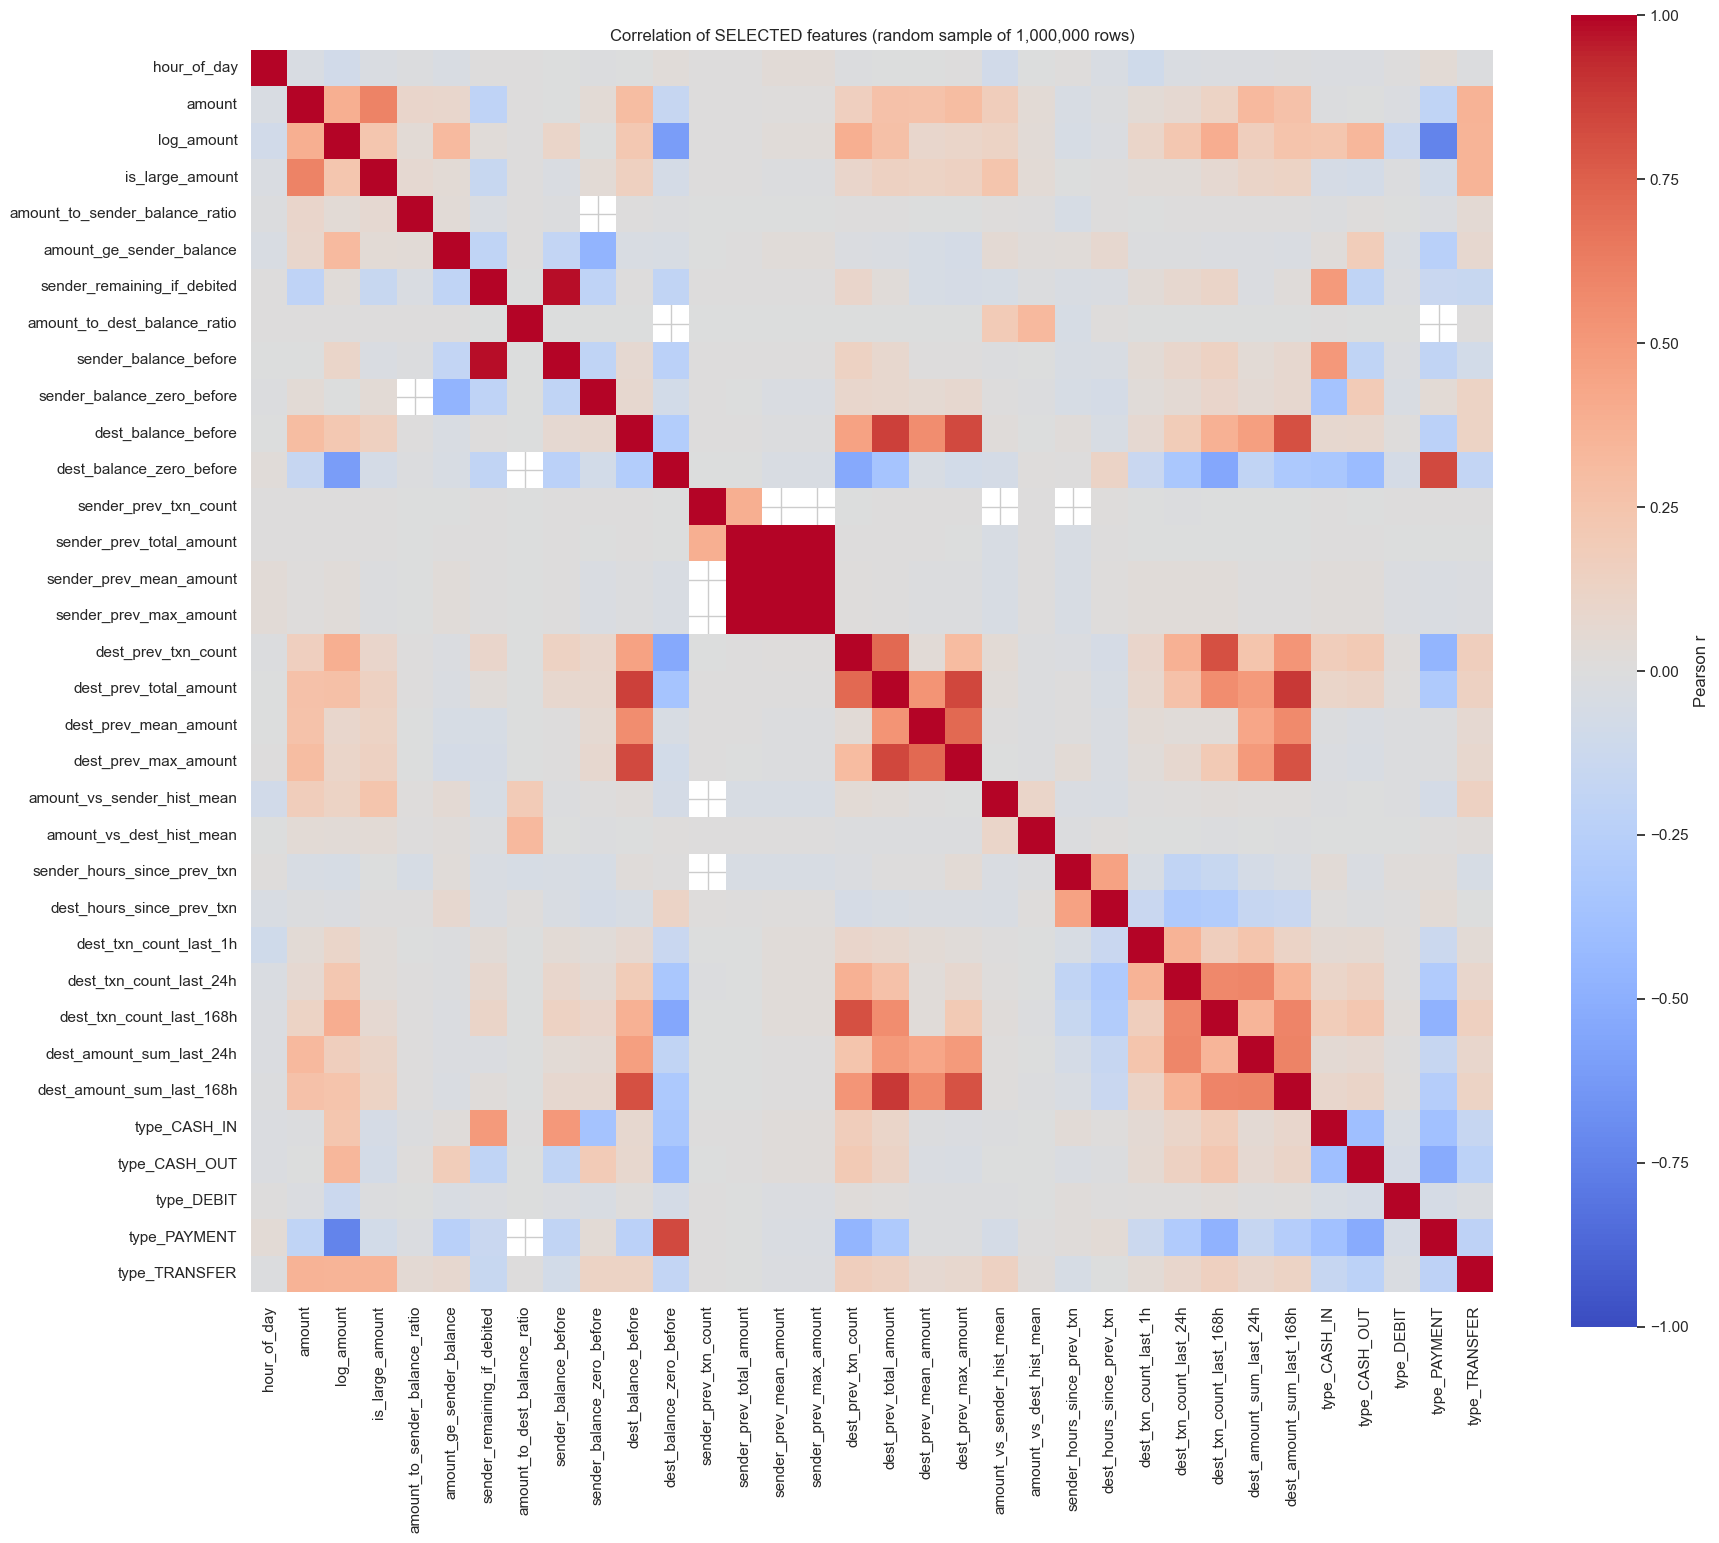

Figure saved -> ..\reports\figures\p3_07_selected_binary_features_by_class.png


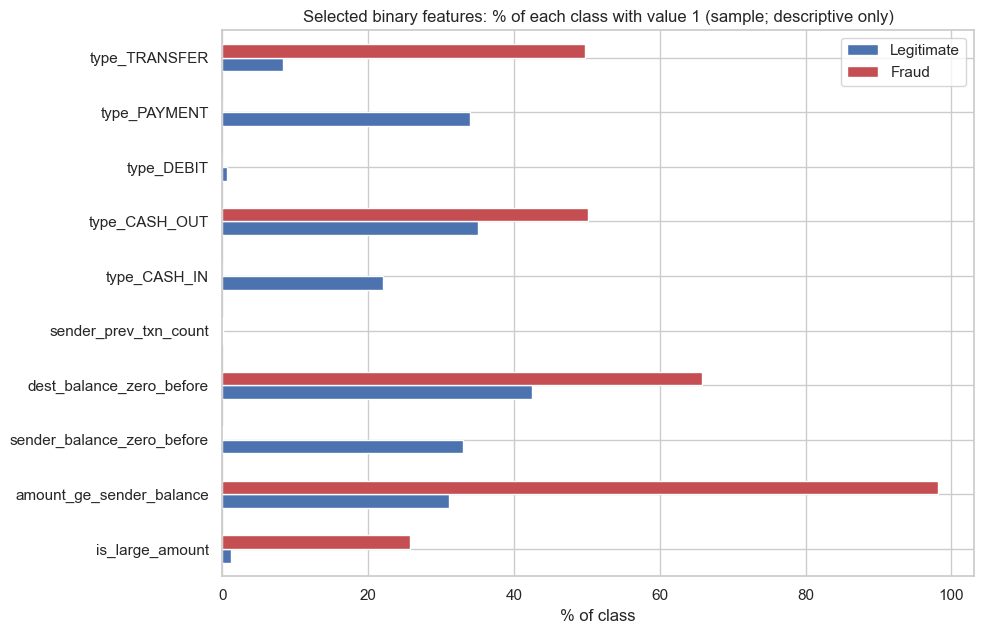

In [22]:
selected_features = [f for f in feat.columns if FINAL_ACTIONS[f].startswith("KEEP")]
excluded_features = [f for f in feat.columns if f not in selected_features]

assert TARGET not in selected_features and not any(m in selected_features for m in META_COLS)
assert all(FEATURE_SPECS[f]["leakage_status"] != "UNSAFE" for f in selected_features), "UNSAFE feature in the final set"
assert all(avail_tbl.set_index("feature").loc[f, "available_at_scoring"] == "YES" for f in selected_features)

final_table = pd.DataFrame({
    "Feature": feat.columns,
    "Group": [FEATURE_SPECS[f]["feature_group"] for f in feat.columns],
    "Description": [FEATURE_SPECS[f]["description"] for f in feat.columns],
    "Data Type": [str(feat[f].dtype) for f in feat.columns],
    "Prediction-Time Available": [FEATURE_SPECS[f]["prediction_time_available"] for f in feat.columns],
    "Leakage Risk": [FEATURE_SPECS[f]["leakage_status"] for f in feat.columns],
    "Final Action": [FINAL_ACTIONS[f] for f in feat.columns]})
md(f"### Features passed to Phase 4: **{len(selected_features)}**")
display(final_table[final_table["Final Action"].str.startswith("KEEP")])
md(f"### Excluded engineered features: **{len(excluded_features)}**")
display(final_table[~final_table["Final Action"].str.startswith("KEEP")][["Feature", "Group", "Leakage Risk", "Final Action"]])

print("\nSelected features by group:")
print(final_table[final_table["Final Action"].str.startswith("KEEP")].groupby("Group").size().to_string())

# ---- figures: correlation of selected features + class comparison of selected indicators ----
sel_num = [c for c in selected_features if feat_sample[c].nunique() > 1]
corr_sel = feat_sample[sel_num].astype("float32").corr()
fig, ax = plt.subplots(figsize=(max(9, 0.45 * len(sel_num) + 3), max(7, 0.4 * len(sel_num) + 2)))
sns.heatmap(corr_sel, cmap="coolwarm", center=0, vmin=-1, vmax=1, annot=len(sel_num) <= 22, fmt=".2f", annot_kws={"size": 7},
            cbar_kws={"label": "Pearson r"}, square=True, ax=ax)
ax.set_title("Correlation of SELECTED features (random sample of 1,000,000 rows)")
plt.tight_layout()
save_fig(fig, "p3_06_selected_feature_correlation.png")
plt.show()

bin_sel = [c for c in selected_features if set(np.unique(feat_sample[c].dropna().to_numpy())) <= {0, 1} and c not in ()]
if bin_sel:
    rates = pd.DataFrame({CLASS_NAMES[k]: [100 * float(feat_sample.loc[y_sample == k, c].mean()) for c in bin_sel] for k in (0, 1)}, index=bin_sel)
    fig, ax = plt.subplots(figsize=(10, 0.45 * len(bin_sel) + 2))
    rates.plot(kind="barh", ax=ax, color=[COLORS[0], COLORS[1]])
    ax.set(title="Selected binary features: % of each class with value 1 (sample; descriptive only)", xlabel="% of class")
    plt.tight_layout()
    save_fig(fig, "p3_07_selected_binary_features_by_class.png")
    plt.show()
CHECK["Final production feature set created"] = True

**What Phase 4 receives.** A table with only prediction-time-safe features (plus the label separately), whose definitions can be reproduced for live transactions. `POTENTIAL_RISK` features that were kept (balance-before features) are clearly marked so that Phase 4 can run an **ablation** ("with vs. without") and report the effect honestly.

## SECTION 23 — Feature Validation

In [23]:
def validate_features(X, y_values, meta, expected_rows, expected_imbalance):
    """Return (report dict, list of failed checks)."""
    rep, fails = {}, []

    def check(name, ok, detail=""):
        rep[name] = {"passed": bool(ok), "detail": detail}
        print(f"[{'PASS' if ok else 'FAIL'}] {name}" + (f" - {detail}" if detail else ""))
        if not ok:
            fails.append(name)

    check("row count preserved", len(X) == expected_rows, f"{len(X):,} rows")
    check("column count", X.shape[1] == len(selected_features), f"{X.shape[1]} feature columns")
    check("target present separately and not in features", TARGET not in X.columns and len(y_values) == len(X))
    dist = {"legitimate": int((y_values == 0).sum()), "fraud": int((y_values == 1).sum())}
    check("target distribution unchanged (no resampling)", dist["legitimate"] == expected_imbalance["legitimate_count"] and dist["fraud"] == expected_imbalance["fraud_count"], str(dist))
    nan_cols = X.columns[X.isna().any()].tolist()
    check("missing values only where undefined by design", all(c in NAN_BY_DESIGN for c in nan_cols), f"{len(nan_cols)} features contain NaN")
    inf_total = int(sum(np.isinf(X[c].to_numpy()).sum() for c in X.columns if pd.api.types.is_float_dtype(X[c])))
    check("no infinite values", inf_total == 0, f"{inf_total} infinite values")
    dup = int(pd.util.hash_pandas_object(X, index=False).duplicated().sum())
    rep["duplicate_feature_rows_info"] = dup
    print(f"[INFO] Rows whose whole feature vector equals an earlier row: {dup:,} (normal: different transactions can share feature values; not removed)")
    import re
    bad_names = [c for c in X.columns if not re.match(r"^[A-Za-z_][A-Za-z0-9_]*$", c)]
    check("feature names valid and unique", not bad_names and X.columns.is_unique, f"invalid: {bad_names}" if bad_names else "")
    non_numeric = [c for c in X.columns if not pd.api.types.is_numeric_dtype(X[c])]
    check("all feature dtypes numeric", not non_numeric, str(non_numeric) if non_numeric else str(sorted({str(t) for t in X.dtypes})))
    check("no UNSAFE feature selected", all(FEATURE_SPECS[c]["leakage_status"] != "UNSAFE" for c in X.columns))
    check("all selected features available at prediction time", all(avail_tbl.set_index("feature").loc[c, "available_at_scoring"] == "YES" for c in X.columns))
    check("chronological order preserved", bool(meta["step"].is_monotonic_increasing))
    check("no-future-information tests passed", CONSISTENCY["prefix_invariance_test_passed"] and CONSISTENCY["streaming_reference_test_passed"])
    return rep, fails


X_final = feat[selected_features]
del feat, feat_sample
gc.collect()
META = X_raw[META_COLS].copy()
VALIDATION_REPORT, VALIDATION_FAILS = validate_features(X_final, y_arr, META, len(X_raw), IMBALANCE)
print("\nVALIDATION RESULT:", "ALL CHECKS PASSED" if not VALIDATION_FAILS else f"FAILED: {VALIDATION_FAILS}")
assert not VALIDATION_FAILS, "Feature validation failed - fix before saving"

[PASS] row count preserved - 6,362,620 rows
[PASS] column count - 34 feature columns
[PASS] target present separately and not in features
[PASS] target distribution unchanged (no resampling) - {'legitimate': 6354407, 'fraud': 8213}
[PASS] missing values only where undefined by design - 10 features contain NaN
[PASS] no infinite values - 0 infinite values
[INFO] Rows whose whole feature vector equals an earlier row: 8,182 (normal: different transactions can share feature values; not removed)
[PASS] feature names valid and unique
[PASS] all feature dtypes numeric - ['float32', 'float64', 'int32', 'int8']
[PASS] no UNSAFE feature selected
[PASS] all selected features available at prediction time
[PASS] chronological order preserved
[PASS] no-future-information tests passed

VALIDATION RESULT: ALL CHECKS PASSED


## SECTION 24 — Save Processed Dataset

Output: `../data/processed/featured_transactions.parquet` containing
`event_id`, `step` (**metadata**, for chronological splitting/replay — *not* features), the **selected features**, and `isFraud` as the last column (the target; Phase 4 must separate it).

If no Parquet engine (`pyarrow`/`fastparquet`) is installed, the notebook falls back to `featured_transactions.csv.gz` and tells you how to enable Parquet. Existing Phase 1/2 files are not touched.

In [24]:
OUTPUT_DF = pd.concat([META.reset_index(drop=True), X_final.reset_index(drop=True), pd.Series(y_arr, name=TARGET)], axis=1)
OUTPUT_PATH_USED, OUTPUT_FORMAT = None, None
try:
    OUTPUT_DF.to_parquet(PROCESSED_PATH, index=False)
    OUTPUT_PATH_USED, OUTPUT_FORMAT = PROCESSED_PATH, "parquet"
except (ImportError, ValueError) as exc:
    print(f"Parquet engine not available ({exc}).")
    print("To enable Parquet later:  pip install pyarrow")
    OUTPUT_DF.to_csv(FALLBACK_PROCESSED_PATH, index=False, compression="gzip")
    OUTPUT_PATH_USED, OUTPUT_FORMAT = FALLBACK_PROCESSED_PATH, "csv.gz"
print(f"Saved {OUTPUT_FORMAT}: {OUTPUT_PATH_USED}  ({Path(OUTPUT_PATH_USED).stat().st_size / 1024 ** 2:,.1f} MB)")
print("Shape:", OUTPUT_DF.shape, "| last column:", OUTPUT_DF.columns[-1])

# read-back verification (only the cheap columns)
if OUTPUT_FORMAT == "parquet":
    back = pd.read_parquet(OUTPUT_PATH_USED, columns=["event_id", "step", TARGET])
else:
    back = pd.read_csv(OUTPUT_PATH_USED, usecols=["event_id", "step", TARGET])
assert len(back) == len(OUTPUT_DF) and int(back[TARGET].sum()) == IMBALANCE["fraud_count"]
print("Read-back check passed (row count and fraud count match).")
del back, OUTPUT_DF
gc.collect()
CHECK["Processed dataset exported"] = True

Saved parquet: ..\data\processed\featured_transactions.parquet  (328.5 MB)
Shape: (6362620, 37) | last column: isFraud
Read-back check passed (row count and fraud count match).


## SECTION 25 — Save Feature Metadata

| File (in `../reports/`) | Content |
|---|---|
| `feature_dictionary.csv` | every engineered feature: group, description, formula, dtype, availability, leakage risk, final action |
| `feature_leakage_audit.csv` | the leakage audit table |
| `selected_features.csv` | the production feature list for Phase 4 |
| `excluded_features.csv` | excluded features and the reason |
| `feature_engineering_summary.json` | constants, counts, decisions, test results |

Phase 2 outputs (`reports/tables`, `reports/figures/01_…16_…`, `reports/eda_summary.json`) are **not** overwritten: all Phase 3 figures use the prefix `p3_`.

In [25]:
dtype_lookup = {f: str(X_final[f].dtype) if f in X_final.columns else final_table.set_index("Feature").loc[f, "Data Type"] for f in FEATURE_SPECS}
feature_dictionary = pd.DataFrame([{
    "Feature": f, "Group": s["feature_group"], "Description": s["description"], "Formula": s["formula"], "Data Type": dtype_lookup[f],
    "Prediction-Time Available": s["prediction_time_available"], "Leakage Risk": s["leakage_status"], "Final Action": FINAL_ACTIONS[f]}
    for f, s in FEATURE_SPECS.items()])
feature_dictionary.to_csv(FEATURE_DICT_PATH, index=False)
leakage_audit.to_csv(LEAKAGE_AUDIT_PATH, index=False)

selected_df = final_table[final_table["Final Action"].str.startswith("KEEP")].reset_index(drop=True)
selected_df.to_csv(SELECTED_PATH, index=False)
excluded_rows = [{"feature": f, "group": FEATURE_SPECS[f]["feature_group"], "leakage_status": FEATURE_SPECS[f]["leakage_status"], "reason": FINAL_ACTIONS[f]}
                 for f in excluded_features]
excluded_rows += [{"feature": TARGET, "group": "Target", "leakage_status": "UNSAFE", "reason": "Label - kept separately as the target, never an input feature"},
                  {"feature": FLAG_COL, "group": "Rule-derived flag", "leakage_status": "POTENTIAL_RISK",
                   "reason": FLAG_DECISION["action"] + " | " + " ".join(FLAG_DECISION["reasons"][:2])} if not FLAG_DECISION["retain"] else
                  {"feature": FLAG_COL, "group": "Rule-derived flag", "leakage_status": "POTENTIAL_RISK", "reason": "Retained as is_flagged_by_rule"},
                  {"feature": "nameOrig", "group": "Identifier", "leakage_status": "SAFE", "reason": "High-cardinality identifier; used only as a key for history features"},
                  {"feature": "nameDest", "group": "Identifier", "leakage_status": "SAFE", "reason": "High-cardinality identifier; used only as a key for history features"},
                  {"feature": "oldbalanceOrg / oldbalanceDest", "group": "Raw balance", "leakage_status": "POTENTIAL_RISK", "reason": "Represented by sender_balance_before / dest_balance_before"},
                  {"feature": "newbalanceOrig / newbalanceDest", "group": "Raw balance", "leakage_status": "UNSAFE", "reason": "Post-transaction information"}]
excluded_df = pd.DataFrame(excluded_rows)
excluded_df.to_csv(EXCLUDED_PATH, index=False)
for p in (FEATURE_DICT_PATH, LEAKAGE_AUDIT_PATH, SELECTED_PATH, EXCLUDED_PATH):
    print("Saved ->", p)
CHECK["Feature dictionary exported"] = True
CHECK["Leakage audit exported"] = True

Saved -> ..\reports\feature_dictionary.csv
Saved -> ..\reports\feature_leakage_audit.csv
Saved -> ..\reports\selected_features.csv
Saved -> ..\reports\excluded_features.csv


In [26]:
def to_jsonable(obj):
    if isinstance(obj, dict):
        return {str(k): to_jsonable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple, set)):
        return [to_jsonable(v) for v in obj]
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, (np.floating, float)):
        return None if not np.isfinite(obj) else float(obj)
    if isinstance(obj, np.bool_):
        return bool(obj)
    if isinstance(obj, Path):
        return str(obj)
    return obj


summary = {
    "phase": "Phase 3 - Feature Engineering",
    "input_file": DATA_PATH,
    "rows": len(X_raw),
    "output_file": str(OUTPUT_PATH_USED), "output_format": OUTPUT_FORMAT,
    "output_columns": {"metadata": META_COLS, "features": selected_features, "target": TARGET},
    "engineered_features_created": len(FEATURE_SPECS),
    "selected_feature_count": len(selected_features),
    "excluded_engineered_feature_count": len(excluded_features),
    "leakage_status_counts": leakage_audit[leakage_audit["feature_name"].isin(FEATURE_SPECS)]["leakage_status"].value_counts().to_dict(),
    "selected_features_by_group": selected_df.groupby("Group").size().to_dict(),
    "excluded_features": {r["feature"]: r["reason"] for r in excluded_rows},
    "class_balance_unchanged": IMBALANCE,
    "frozen_parameters_fitted_on_training_period": FE_PARAMS,
    "event_order": "stable order by (step, original row position); history features use strictly earlier events only",
    "isFlaggedFraud_decision": FLAG_DECISION,
    "near_zero_variance_features": NZV_FEATURES, "constant_features": CONSTANT_FEATURES,
    "duplicate_features": DUPLICATE_FEATURES, "identifier_like_features": ID_LIKE,
    "high_correlation_pairs_reported_not_deleted": HIGH_CORR_PAIRS.to_dict(orient="records") if len(HIGH_CORR_PAIRS) else [],
    "nan_by_design_features": NAN_BY_DESIGN,
    "consistency_tests": CONSISTENCY,
    "validation": {k: v for k, v in VALIDATION_REPORT.items()},
    "figures": sorted(p.name for p in FIGURES_DIR.glob("p3_*.png")),
    "runtime_seconds": round(time.time() - PHASE3_START, 1),
    "no_model_trained": True,
}
with open(SUMMARY_PATH, "w", encoding="utf-8") as fh:
    json.dump(to_jsonable(summary), fh, indent=2)
print("Saved ->", SUMMARY_PATH)

Saved -> ..\reports\feature_engineering_summary.json


## SECTION 26 — Final Phase 3 Summary

In [27]:
print("=" * 78)
print("PHASE 3 — FINAL SUMMARY (all values computed from the data)")
print("=" * 78)
print(f"Rows processed                         : {len(X_raw):,}")
print(f"Engineered features created            : {len(FEATURE_SPECS)}")
print(f"  SAFE / POTENTIAL_RISK / UNSAFE       : " + " / ".join(str(summary['leakage_status_counts'].get(k, 0)) for k in ("SAFE", "POTENTIAL_RISK", "UNSAFE")))
print(f"Features passed to Phase 4             : {len(selected_features)}")
print(f"Features excluded                      : {len(excluded_features)}")
print(f"Class balance (unchanged)              : fraud {IMBALANCE['fraud_count']:,} | legitimate {IMBALANCE['legitimate_count']:,} | "
      f"{IMBALANCE['fraud_percentage']:.4f}% fraud | 1:{IMBALANCE['imbalance_ratio']:,.1f}")
print(f"isFlaggedFraud decision                : {FLAG_DECISION['action']}")
print(f"Near-zero-variance features excluded   : {NZV_FEATURES if NZV_FEATURES else 'none'}")
print(f"No-future-information tests            : prefix-invariance {'PASS' if CONSISTENCY['prefix_invariance_test_passed'] else 'FAIL'}, "
      f"streaming reference {'PASS' if CONSISTENCY['streaming_reference_test_passed'] else 'FAIL'}")
print(f"Output dataset                         : {OUTPUT_PATH_USED}")
print("\nSelected features:")
for g, grp in selected_df.groupby("Group"):
    print(f"  [{g}] " + ", ".join(grp["Feature"].tolist()))
print("\nReminders for Phase 4:")
print("  * Split CHRONOLOGICALLY using the 'step' column (never randomly).")
print("  * Separate the target column 'isFraud'; do not use event_id/step as features.")
print("  * Handle class imbalance ONLY inside the training data of Phase 4.")
print("  * Run an ablation on the POTENTIAL_RISK balance-before features.")
print("  * Store FE_PARAMS (frozen constants) with the model for the streaming phase.")

PHASE 3 — FINAL SUMMARY (all values computed from the data)
Rows processed                         : 6,362,620
Engineered features created            : 58
  SAFE / POTENTIAL_RISK / UNSAFE       : 42 / 9 / 7
Features passed to Phase 4             : 34
Features excluded                      : 24
Class balance (unchanged)              : fraud 8,213 | legitimate 6,354,407 | 0.1291% fraud | 1:773.7
isFlaggedFraud decision                : Exclude
Near-zero-variance features excluded   : ['is_zero_amount', 'sender_txn_count_last_1h', 'sender_txn_count_last_24h', 'sender_txn_count_last_168h', 'sender_amount_sum_last_24h', 'sender_amount_sum_last_168h', 'sender_new_counterparties_last_24h', 'sender_new_counterparties_last_168h']
No-future-information tests            : prefix-invariance PASS, streaming reference PASS
Output dataset                         : ..\data\processed\featured_transactions.parquet

Selected features:
  [Account behaviour] sender_prev_txn_count, sender_prev_total_amount,

## SECTION 27 — Phase 3 Checklist

In [28]:
CHECK["No model trained"] = True
ORDER = ["Dataset loaded successfully", "Target identified", "Temporal features created", "Amount features created", "Balance features reviewed",
         "Account behaviour features reviewed", "Velocity features created where safe", "Transaction type encoded", "isFlaggedFraud evaluated",
         "Missing values handled", "Infinite values checked", "Outliers reviewed", "Redundant features reviewed", "Leakage audit completed",
         "Prediction-time availability checked", "Chronological ordering preserved", "Final production feature set created",
         "Feature dictionary exported", "Leakage audit exported", "Processed dataset exported", "No model trained"]
print("PHASE 3 — FEATURE ENGINEERING CHECKLIST\n")
for item in ORDER:
    print(f"[{'x' if CHECK.get(item) else ' '}] {item}")
print(f"\nCompleted {sum(bool(CHECK.get(i)) for i in ORDER)}/{len(ORDER)} items in {time.time() - PHASE3_START:,.0f} seconds.")

PHASE 3 — FEATURE ENGINEERING CHECKLIST

[x] Dataset loaded successfully
[x] Target identified
[x] Temporal features created
[x] Amount features created
[x] Balance features reviewed
[x] Account behaviour features reviewed
[x] Velocity features created where safe
[x] Transaction type encoded
[x] isFlaggedFraud evaluated
[x] Missing values handled
[x] Infinite values checked
[x] Outliers reviewed
[x] Redundant features reviewed
[x] Leakage audit completed
[x] Prediction-time availability checked
[x] Chronological ordering preserved
[x] Final production feature set created
[x] Feature dictionary exported
[x] Leakage audit exported
[x] Processed dataset exported
[x] No model trained

Completed 21/21 items in 345 seconds.
